<a href="https://colab.research.google.com/github/stevej108/Data-Science-Projects/blob/main/Channel_Mix_Media_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
channel = pd.read_csv('/content/spend_by_channel.csv')
traffic = pd.read_csv('/content/traffic.csv')

print("Channel Spend", channel.head())
print("Traffic", traffic.head())

Channel Spend    Year Quarter Month LINEAR TV RADIO  OOH STREAMING AUDIO DIGITAL VIDEO  \
0  FY24      Q1   FEB      142     0     0              0            76    
1  FY24      Q1   MAR      739   704     0            877         1,386    
2  FY24      Q1   APR      261   226     0            395           653    
3  FY24      Q2   MAY      216   214     0            310           704    
4  FY24      Q2   JUN      139   105     0            400           638    

   PAID SOCIAL MEDIA  INFLUENCERS FEES   TOTALS  
0                  0                 0     218   
1                386                 0   4,093   
2                164                 0   1,700   
3                  0                 0   1,445   
4                224                 0   1,506   
Traffic    Store       Location Month  Year WeekEndDate  Exits   Exits LY   \
0      2  MILWAUKEE, WI   FEB  2026    2/7/2026   4,651      4,267   
1      2  MILWAUKEE, WI   FEB  2026   2/14/2026   4,151      4,038   
2      2  M

In [3]:
traffic.columns.to_list()

['Store',
 'Location',
 'Month',
 'Year',
 'WeekEndDate',
 ' Exits ',
 ' Exits LY ',
 '# Sale Txns',
 '# Sale Txns LY']

# Cleaning

In [4]:

traffic = traffic.copy()

numeric_cols = [
    " Exits ",
    " Exits LY ",
    "# Sale Txns",
    "# Sale Txns LY"
]

for col in numeric_cols:
    traffic[col] = (
        traffic[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .pipe(pd.to_numeric, errors="coerce")
    )

traffic["Comp_Exits"] = (
    (traffic[" Exits "] - traffic[" Exits LY "])
    / traffic[" Exits LY "]
) * 100

traffic["Comp_Txns"] = (
    (traffic["# Sale Txns"] - traffic["# Sale Txns LY"])
    / traffic["# Sale Txns LY"]
) * 100

# Protect against invalid LY denominators
traffic.loc[traffic[" Exits LY "] <= 0, "Comp_Exits"] = np.nan
traffic.loc[traffic["# Sale Txns LY"] <= 0, "Comp_Txns"] = np.nan

traffic["WeekEndDate"] = pd.to_datetime(traffic["WeekEndDate"])

In [5]:
# Add channel month

import pandas as pd
import numpy as np

channel = channel.copy()

# --------------------------------------------------
# 1. Clean column names
# --------------------------------------------------

channel.columns = (
    channel.columns
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# --------------------------------------------------
# 2. Convert FY label to fiscal year number
#    FY24 -> 2024
# --------------------------------------------------

channel["Fiscal_Year"] = (
    channel["Year"]
    .str.extract(r"(\d{2})")[0]
    .astype(int)
    + 2000
)

# --------------------------------------------------
# 3. Convert month abbreviation to month number
# --------------------------------------------------

channel["Month_Num"] = pd.to_datetime(
    channel["Month"],
    format="%b"
).dt.month

# --------------------------------------------------
# 4. Determine calendar year
#
# Fiscal year begins in February:
# FEB-DEC belong to FY year
# JAN belongs to following calendar year
# --------------------------------------------------

channel["Calendar_Year"] = np.where(
    channel["Month_Num"] >= 2,
    channel["Fiscal_Year"],
    channel["Fiscal_Year"] + 1
)

# --------------------------------------------------
# 5. Create actual calendar month
# --------------------------------------------------

channel["channel_Month"] = pd.to_datetime(
    dict(
        year=channel["Calendar_Year"],
        month=channel["Month_Num"],
        day=1
    )
)

traffic["channel_Month"] = (
    traffic["WeekEndDate"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

In [6]:
# Clean Spend

channel_cols = [
    "LINEAR TV",
    "RADIO",
    "OOH",
    "STREAMING AUDIO",
    "DIGITAL VIDEO",
    "PAID SOCIAL MEDIA",
    "INFLUENCERS FEES"
]

for col in channel_cols:
    channel[col] = (
        channel[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.strip()
        .replace({"": np.nan, "nan": np.nan})
        .pipe(pd.to_numeric, errors="coerce")
    )

In [7]:
# Clean Spend Totals
channel["TOTALS"] = (
    channel["TOTALS"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.strip()
    .replace({"": np.nan, "nan": np.nan})
    .pipe(pd.to_numeric, errors="coerce")
)

In [8]:
# Validate
print(
    channel[
        [
            "Year",
            "Quarter",
            "Month",
            "Fiscal_Year",
            "Calendar_Year",
            "channel_Month"
        ]
    ].head(15)
)

print("\nChannel dtypes:")
print(channel[channel_cols].dtypes)

print("\nDate range:")
print(channel["channel_Month"].min())
print(channel["channel_Month"].max())

print("\nMissing spend values:")
print(channel[channel_cols].isna().sum())

channel["Calculated_Total"] = channel[channel_cols].sum(axis=1)

channel["Total_Difference"] = (
    channel["TOTALS"] - channel["Calculated_Total"]
)

print(
    channel[
        ["channel_Month", "TOTALS", "Calculated_Total", "Total_Difference"]
    ].head(20)
)

    Year Quarter Month  Fiscal_Year  Calendar_Year channel_Month
0   FY24      Q1   FEB         2024           2024    2024-02-01
1   FY24      Q1   MAR         2024           2024    2024-03-01
2   FY24      Q1   APR         2024           2024    2024-04-01
3   FY24      Q2   MAY         2024           2024    2024-05-01
4   FY24      Q2   JUN         2024           2024    2024-06-01
5   FY24      Q2   JUL         2024           2024    2024-07-01
6   FY24      Q3   AUG         2024           2024    2024-08-01
7   FY24      Q3   SEP         2024           2024    2024-09-01
8   FY24      Q3   OCT         2024           2024    2024-10-01
9   FY24      Q4   NOV         2024           2024    2024-11-01
10  FY24      Q4   DEC         2024           2024    2024-12-01
11  FY24      Q4   JAN         2024           2025    2025-01-01
12  FY25      Q1   FEB         2025           2025    2025-02-01
13  FY25      Q1   MAR         2025           2025    2025-03-01
14  FY25      Q1   APR   

In [9]:
print(
    traffic[
        [
            "Store",
            "Location",
            "WeekEndDate",
            "channel_Month",
            "Comp_Exits",
            "Comp_Txns",
        ]
    ].head()
)

print("\nTraffic date range:")
print(traffic["WeekEndDate"].min())
print(traffic["WeekEndDate"].max())

print("\nMissing comp metrics:")
print(
    traffic[
        ["Comp_Exits", "Comp_Txns"]
    ].isna().sum()
)
print("\nTraffic Shape")
print(traffic.shape)

   Store       Location WeekEndDate channel_Month  Comp_Exits  Comp_Txns
0      2  MILWAUKEE, WI  2026-02-07    2026-02-01    8.999297   4.403048
1      2  MILWAUKEE, WI  2026-02-14    2026-02-01    2.798415  -0.663130
2      2  MILWAUKEE, WI  2026-02-21    2026-02-01    1.234291  -1.120332
3      2  MILWAUKEE, WI  2026-02-28    2026-02-01   -4.544147  -8.756757
4      2  MILWAUKEE, WI  2026-03-07    2026-03-01    4.997117   0.848356

Traffic date range:
2024-02-10 00:00:00
2026-08-15 00:00:00

Missing comp metrics:
Comp_Exits    467
Comp_Txns     593
dtype: int64

Traffic Shape
(104482, 12)


In [10]:
# Checking for duplicates before merging

duplicates = channel["channel_Month"].duplicated().sum()

print(f"Duplicate channel months: {duplicates}")

Duplicate channel months: 0


## Feature Engineering


In [11]:
MEDIA_CHANNELS = [
    "LINEAR TV",
    "RADIO",
    "OOH",
    "STREAMING AUDIO",
    "DIGITAL VIDEO",
    "PAID SOCIAL MEDIA",
    "INFLUENCERS FEES",
]

# month-over-month spend change
channel = channel.sort_values("channel_Month").copy()

for col in MEDIA_CHANNELS:
    channel[f"{col}_Change"] = channel[col].diff()


# Direction Variable
for col in MEDIA_CHANNELS:
    channel[f"{col}_Direction"] = np.select(
        [
            channel[f"{col}_Change"] > 0,
            channel[f"{col}_Change"] < 0,
        ],
        [
            1,
            -1,
        ],
        default=0
    )

# Log-transformed spend
for col in MEDIA_CHANNELS:
    channel[f"{col}_Log"] = np.log1p(channel[col])

# 1 and 2 month Lags
for col in MEDIA_CHANNELS:
    channel[f"{col}_Lag1"] = channel[col].shift(1)
    channel[f"{col}_Lag2"] = channel[col].shift(2)


# 1 and 2 month Lags for Change in Spend
for channel_name in MEDIA_CHANNELS:

    # Current month change
    change_col = f"{channel_name}_Change"

    # Previous month's change in spend
    channel[f"{channel_name}_Change_Lag1"] = (
        channel[change_col].shift(1)
    )

    # Change in spend two months ago
    channel[f"{channel_name}_Change_Lag2"] = (
        channel[change_col].shift(2)
    )

    # Adding log spend change

for channel_name in MEDIA_CHANNELS:

    channel[
        f"{channel_name}_Log_Change"
    ] = (
        np.log1p(channel[channel_name])
        .diff()
    )

In [12]:
# Merge the data

panel = traffic.merge(
    channel,
    on="channel_Month",
    how="left",
    validate="many_to_one",
    suffixes=("", "_channel")
)

In [13]:
panel = panel.sort_values(
    ["Store", "WeekEndDate"]
).reset_index(drop=True)

In [14]:
# Validate the merge

print(f"Traffic rows: {len(traffic):,}")
print(f"Panel rows:   {len(panel):,}")

print("\nPanel date range:")
print(panel["channel_Month"].min())
print(panel["channel_Month"].max())

print("\nMissing media:")
print(
    panel[
        [
            "LINEAR TV",
            "RADIO",
            "OOH",
            "STREAMING AUDIO",
            "DIGITAL VIDEO",
            "PAID SOCIAL MEDIA",
            "INFLUENCERS FEES",
        ]
    ].isna().sum()
)

Traffic rows: 104,482
Panel rows:   104,482

Panel date range:
2024-02-01 00:00:00
2026-08-01 00:00:00

Missing media:
LINEAR TV            2815
RADIO                6132
OOH                  2815
STREAMING AUDIO      2815
DIGITAL VIDEO        2815
PAID SOCIAL MEDIA    2815
INFLUENCERS FEES     2815
dtype: int64


In [15]:
# Store level feature engineering
panel["Comp_Exits_Change"] = (
    panel.groupby("Store")["Comp_Exits"]
    .diff()
)

panel["Comp_Txns_Change"] = (
    panel.groupby("Store")["Comp_Txns"]
    .diff()
)

In [16]:
# Seasonality Controls
panel["Year_Num"] = panel["WeekEndDate"].dt.year
panel["Month_Num"] = panel["WeekEndDate"].dt.month
panel["Week_Num"] = panel["WeekEndDate"].dt.isocalendar().week.astype(int)
panel["Quarter_Num"] = panel["WeekEndDate"].dt.quarter

# Monthly Panel Creation


In [17]:
# ============================================================
# CREATE STORE × MONTH TRAFFIC PANEL
# ============================================================

monthly_traffic = (
    traffic
    .groupby(
        ["Store", "Location", "channel_Month"],
        as_index=False
    )
    .agg(
        Exits=(" Exits ", "sum"),
        Exits_LY=(" Exits LY ", "sum"),
        Sale_Txns=("# Sale Txns", "sum"),
        Sale_Txns_LY=("# Sale Txns LY", "sum"),
        Weeks_In_Month=("WeekEndDate", "nunique")
    )
)

# Calculate monthly comparable performance
monthly_traffic["Comp_Exits"] = (
    (monthly_traffic["Exits"] - monthly_traffic["Exits_LY"])
    / monthly_traffic["Exits_LY"]
) * 100

monthly_traffic["Comp_Txns"] = (
    (monthly_traffic["Sale_Txns"] - monthly_traffic["Sale_Txns_LY"])
    / monthly_traffic["Sale_Txns_LY"]
) * 100

In [18]:
monthly_traffic.loc[
    monthly_traffic["Exits_LY"] <= 0,
    "Comp_Exits"
] = np.nan

monthly_traffic.loc[
    monthly_traffic["Sale_Txns_LY"] <= 0,
    "Comp_Txns"
] = np.nan

In [19]:
print(monthly_traffic.head())

print("\nShape:")
print(monthly_traffic.shape)

print("\nStores:")
print(monthly_traffic["Store"].nunique())

print("\nDate range:")
print(
    monthly_traffic["channel_Month"].min(),
    "to",
    monthly_traffic["channel_Month"].max()
)

print("\nWeeks per store-month:")
print(
    monthly_traffic["Weeks_In_Month"]
    .value_counts()
    .sort_index()
)

print("\nMissing comps:")
print(
    monthly_traffic[
        ["Comp_Exits", "Comp_Txns"]
    ].isna().sum()
)

   Store       Location channel_Month    Exits  Exits_LY  Sale_Txns  \
0      2  MILWAUKEE, WI    2024-02-01  14548.0   16581.0     7671.0   
1      2  MILWAUKEE, WI    2024-03-01  24903.0   25981.0    13231.0   
2      2  MILWAUKEE, WI    2024-04-01  21628.0   25170.0    11427.0   
3      2  MILWAUKEE, WI    2024-05-01  22561.0   23898.0    12029.0   
4      2  MILWAUKEE, WI    2024-06-01  30881.0   35110.0    16239.0   

   Sale_Txns_LY  Weeks_In_Month  Comp_Exits  Comp_Txns  
0        8163.0               3  -12.261022  -6.027196  
1       13495.0               5   -4.149186  -1.956280  
2       13012.0               4  -14.072308 -12.181064  
3       12640.0               4   -5.594610  -4.833861  
4       17954.0               5  -12.045001  -9.552189  

Shape:
(25779, 10)

Stores:
1095

Date range:
2024-02-01 00:00:00 to 2026-08-01 00:00:00

Weeks per store-month:
Weeks_In_Month
1      865
2      542
3     2237
4    14853
5     7282
Name: count, dtype: int64

Missing comps:
Comp_

In [20]:
# merge for montly panel

monthly_panel = monthly_traffic.merge(
    channel,
    on="channel_Month",
    how="left",
    validate="many_to_one",
    suffixes=("", "_channel")
)

monthly_panel = monthly_panel.sort_values(
    ["Store", "channel_Month"]
).reset_index(drop=True)


# validate

print(f"Monthly traffic rows: {len(monthly_traffic):,}")
print(f"Monthly panel rows:   {len(monthly_panel):,}")

print("\nStores:")
print(monthly_panel["Store"].nunique())

print("\nMonths:")
print(monthly_panel["channel_Month"].nunique())

print("\nMissing media:")
print(
    monthly_panel[MEDIA_CHANNELS]
    .isna()
    .sum()
)

Monthly traffic rows: 25,779
Monthly panel rows:   25,779

Stores:
1095

Months:
31

Missing media:
LINEAR TV             987
RADIO                1832
OOH                   987
STREAMING AUDIO       987
DIGITAL VIDEO         987
PAID SOCIAL MEDIA     987
INFLUENCERS FEES      987
dtype: int64


In [21]:
print(
    monthly_panel.groupby("channel_Month")["Store"]
    .nunique()
)

channel_Month
2024-02-01     665
2024-03-01     670
2024-04-01     739
2024-05-01     670
2024-06-01     676
2024-07-01     679
2024-08-01     683
2024-09-01     672
2024-10-01     685
2024-11-01     770
2024-12-01     781
2025-01-01     774
2025-02-01     817
2025-03-01     814
2025-04-01     907
2025-05-01     819
2025-06-01     831
2025-07-01     833
2025-08-01     843
2025-09-01     845
2025-10-01     843
2025-11-01     864
2025-12-01     993
2026-01-01     960
2026-02-01     962
2026-03-01     970
2026-04-01    1036
2026-05-01     983
2026-06-01    1004
2026-07-01     995
2026-08-01     987
Name: Store, dtype: int64


In [22]:
media_analysis = (
    channel[
        ["channel_Month"] + MEDIA_CHANNELS
    ]
    .drop_duplicates("channel_Month")
    .sort_values("channel_Month")
    .reset_index(drop=True)
)

print(media_analysis.head())
print(media_analysis.shape)

  channel_Month  LINEAR TV  RADIO  OOH  STREAMING AUDIO  DIGITAL VIDEO  \
0    2024-02-01        142    0.0    0                0             76   
1    2024-03-01        739  704.0    0              877           1386   
2    2024-04-01        261  226.0    0              395            653   
3    2024-05-01        216  214.0    0              310            704   
4    2024-06-01        139  105.0    0              400            638   

   PAID SOCIAL MEDIA  INFLUENCERS FEES  
0                  0                 0  
1                386                 0  
2                164                 0  
3                  0                 0  
4                224                 0  
(30, 8)


# Evaluating Channel Correlations, Collinearity, and VIF


In [23]:
channel_corr = (
    media_analysis[MEDIA_CHANNELS]
    .corr()
)

print(channel_corr.round(3))

                   LINEAR TV  RADIO    OOH  STREAMING AUDIO  DIGITAL VIDEO  \
LINEAR TV              1.000  0.674  0.200            0.724          0.691   
RADIO                  0.674  1.000  0.437            0.791          0.828   
OOH                    0.200  0.437  1.000            0.340          0.396   
STREAMING AUDIO        0.724  0.791  0.340            1.000          0.914   
DIGITAL VIDEO          0.691  0.828  0.396            0.914          1.000   
PAID SOCIAL MEDIA      0.303  0.276  0.228            0.232          0.415   
INFLUENCERS FEES       0.233  0.441  0.650            0.350          0.482   

                   PAID SOCIAL MEDIA  INFLUENCERS FEES  
LINEAR TV                      0.303             0.233  
RADIO                          0.276             0.441  
OOH                            0.228             0.650  
STREAMING AUDIO                0.232             0.350  
DIGITAL VIDEO                  0.415             0.482  
PAID SOCIAL MEDIA              1.

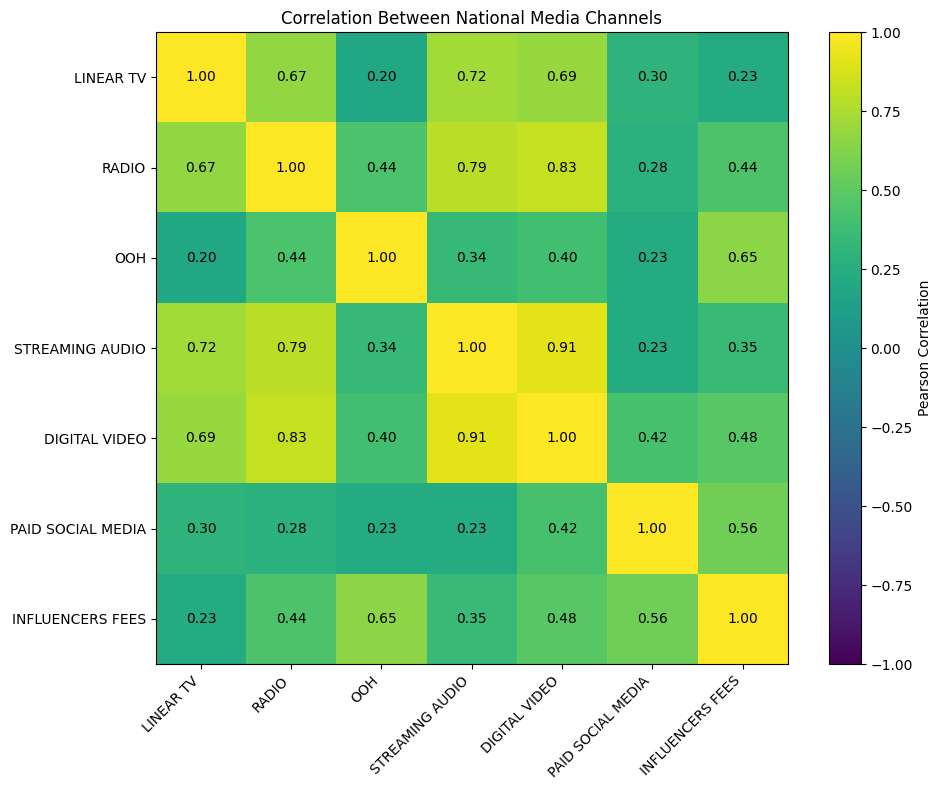

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    channel_corr,
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(MEDIA_CHANNELS)))
ax.set_yticks(range(len(MEDIA_CHANNELS)))

ax.set_xticklabels(
    MEDIA_CHANNELS,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(MEDIA_CHANNELS)

for i in range(len(MEDIA_CHANNELS)):
    for j in range(len(MEDIA_CHANNELS)):
        ax.text(
            j,
            i,
            f"{channel_corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

ax.set_title(
    "Correlation Between National Media Channels"
)

fig.colorbar(im, ax=ax, label="Pearson Correlation")

plt.tight_layout()
plt.show()

In [25]:
def high_correlation_pairs(
    corr_matrix,
    threshold=0.70
):
    """
    Return unique variable pairs with absolute
    correlation >= threshold.
    """

    pairs = []

    columns = corr_matrix.columns

    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):

            corr = corr_matrix.iloc[i, j]

            if abs(corr) >= threshold:
                pairs.append({
                    "Channel_1": columns[i],
                    "Channel_2": columns[j],
                    "Correlation": corr
                })

    return (
        pd.DataFrame(pairs)
        .sort_values(
            "Correlation",
            key=abs,
            ascending=False
        )
        .reset_index(drop=True)
    )

In [26]:
high_corr = high_correlation_pairs(
    channel_corr,
    threshold=0.70
)

print(high_corr)

         Channel_1        Channel_2  Correlation
0  STREAMING AUDIO    DIGITAL VIDEO     0.914366
1            RADIO    DIGITAL VIDEO     0.827701
2            RADIO  STREAMING AUDIO     0.791322
3        LINEAR TV  STREAMING AUDIO     0.723738


we have multiple channels which show a relatively high correlation with one another

In [27]:
# Checking VIF

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

def calculate_vif(df, features):
    """
    Calculate Variance Inflation Factor for a set
    of numeric features.
    """

    X = (
        df[features]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )

    # Standardization does not change VIF, but helps
    # numerical stability when spend scales differ.
    scaler = StandardScaler()

    X_scaled = pd.DataFrame(
        scaler.fit_transform(X),
        columns=features,
        index=X.index
    )

    vif = pd.DataFrame({
        "Feature": features,
        "VIF": [
            variance_inflation_factor(
                X_scaled.values,
                i
            )
            for i in range(len(features))
        ]
    })

    return (
        vif
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )

In [28]:
channel_vif = calculate_vif(
    media_analysis,
    MEDIA_CHANNELS
)

print(channel_vif)

             Feature       VIF
0      DIGITAL VIDEO  9.955143
1    STREAMING AUDIO  8.109261
2              RADIO  3.817760
3   INFLUENCERS FEES  2.683299
4          LINEAR TV  2.422773
5  PAID SOCIAL MEDIA  1.977828
6                OOH  1.925841


In [29]:
X = (
    media_analysis[MEDIA_CHANNELS]
    .dropna()
)

matrix_rank = np.linalg.matrix_rank(X.values)

print(f"Number of channels: {X.shape[1]}")
print(f"Matrix rank:        {matrix_rank}")

Number of channels: 7
Matrix rank:        7


In [30]:
# Zero Spend Analysis

zero_spend = pd.DataFrame({
    "Channel": MEDIA_CHANNELS,
    "Zero_Months": [
        (media_analysis[col] == 0).sum()
        for col in MEDIA_CHANNELS
    ],
    "Total_Months": [
        media_analysis[col].notna().sum()
        for col in MEDIA_CHANNELS
    ]
})

zero_spend["Pct_Zero"] = (
    zero_spend["Zero_Months"]
    / zero_spend["Total_Months"]
    * 100
)

zero_spend = zero_spend.sort_values(
    "Pct_Zero",
    ascending=False
)

print(zero_spend)

             Channel  Zero_Months  Total_Months   Pct_Zero
6   INFLUENCERS FEES           12            30  40.000000
2                OOH           10            30  33.333333
1              RADIO            4            29  13.793103
0          LINEAR TV            4            30  13.333333
5  PAID SOCIAL MEDIA            4            30  13.333333
3    STREAMING AUDIO            3            30  10.000000
4      DIGITAL VIDEO            1            30   3.333333


## Spend Analysis


In [31]:
# National Performance Panel

national_monthly = (
    monthly_panel
    .groupby("channel_Month", as_index=False)
    .agg(
        Exits=("Exits", "sum"),
        Exits_LY=("Exits_LY", "sum"),
        Sale_Txns=("Sale_Txns", "sum"),
        Sale_Txns_LY=("Sale_Txns_LY", "sum")
    )
)

national_monthly["Comp_Exits"] = (
    (national_monthly["Exits"] - national_monthly["Exits_LY"])
    / national_monthly["Exits_LY"]
) * 100

national_monthly["Comp_Txns"] = (
    (national_monthly["Sale_Txns"] - national_monthly["Sale_Txns_LY"])
    / national_monthly["Sale_Txns_LY"]
) * 100


national_monthly = national_monthly.merge(
    channel[
        ["channel_Month"] + MEDIA_CHANNELS
    ],
    on="channel_Month",
    how="left",
    validate="one_to_one"
)

In [32]:
national_corr = national_monthly[
    MEDIA_CHANNELS +
    ["Comp_Exits", "Comp_Txns"]
].corr()

channel_outcome_corr = national_corr.loc[
    MEDIA_CHANNELS,
    ["Comp_Exits", "Comp_Txns"]
]

print(
    channel_outcome_corr
    .sort_values("Comp_Exits", ascending=False)
    .round(3)
)

                   Comp_Exits  Comp_Txns
LINEAR TV               0.229      0.362
STREAMING AUDIO         0.147      0.290
RADIO                   0.087      0.263
PAID SOCIAL MEDIA      -0.009     -0.052
DIGITAL VIDEO          -0.018      0.126
OOH                    -0.121     -0.027
INFLUENCERS FEES       -0.226     -0.076


In [33]:
from scipy.stats import pearsonr


def store_channel_correlations(
    df,
    channels,
    outcomes=("Comp_Exits", "Comp_Txns"),
    feature_suffix="",
    min_months=12
):
    """
    Calculate store-level Pearson correlations between
    media features and store performance outcomes.
    """

    results = []

    for store, store_df in df.groupby("Store"):

        location = store_df["Location"].iloc[0]

        for channel_name in channels:

            feature = f"{channel_name}{feature_suffix}"

            for outcome in outcomes:

                temp = (
                    store_df[
                        [feature, outcome]
                    ]
                    .replace([np.inf, -np.inf], np.nan)
                    .dropna()
                )

                if len(temp) < min_months:
                    continue

                # Require actual variation
                if (
                    temp[feature].nunique() < 2
                    or temp[outcome].nunique() < 2
                ):
                    continue

                r, p = pearsonr(
                    temp[feature],
                    temp[outcome]
                )

                results.append({
                    "Store": store,
                    "Location": location,
                    "Channel": channel_name,
                    "Feature": feature,
                    "Outcome": outcome,
                    "Correlation": r,
                    "P_Value": p,
                    "N_Months": len(temp)
                })

    return pd.DataFrame(results)

In [34]:
store_corr = store_channel_correlations(
    monthly_panel,
    MEDIA_CHANNELS
)

print(store_corr.head())

   Store       Location    Channel    Feature     Outcome  Correlation  \
0      2  MILWAUKEE, WI  LINEAR TV  LINEAR TV  Comp_Exits     0.234889   
1      2  MILWAUKEE, WI  LINEAR TV  LINEAR TV   Comp_Txns     0.284027   
2      2  MILWAUKEE, WI      RADIO      RADIO  Comp_Exits     0.333601   
3      2  MILWAUKEE, WI      RADIO      RADIO   Comp_Txns     0.277962   
4      2  MILWAUKEE, WI        OOH        OOH  Comp_Exits     0.247291   

    P_Value  N_Months  
0  0.211504        30  
1  0.128234        30  
2  0.076972        29  
3  0.144297        29  
4  0.187675        30  


In [35]:
store_corr.sort_values("Correlation",ascending=False)

,Store,Location,Channel,Feature,Outcome,Correlation,P_Value,N_Months
11572,1509,"LAWRENCE, KS (PINE RDGE PZA)",DIGITAL VIDEO,DIGITAL VIDEO,Comp_Exits,0.888506,3.753065e-07,19
4594,892,"MIDDLETOWN, OH",OOH,OOH,Comp_Exits,0.871190,1.461020e-08,25
11573,1509,"LAWRENCE, KS (PINE RDGE PZA)",DIGITAL VIDEO,DIGITAL VIDEO,Comp_Txns,0.870923,1.224689e-06,19
11570,1509,"LAWRENCE, KS (PINE RDGE PZA)",STREAMING AUDIO,STREAMING AUDIO,Comp_Exits,0.870296,1.273340e-06,19
11571,1509,"LAWRENCE, KS (PINE RDGE PZA)",STREAMING AUDIO,STREAMING AUDIO,Comp_Txns,0.856527,2.858489e-06,19
...,...,...,...,...,...,...,...,...
4210,862,"OVERLAND PARK, KS",INFLUENCERS FEES,INFLUENCERS FEES,Comp_Exits,-0.965244,1.577557e-12,21
1984,375,"TAMPA, FL (UNIVERSITY MALL)",INFLUENCERS FEES,INFLUENCERS FEES,Comp_Exits,-0.972334,3.590058e-12,19
5905,1060,"DEWITT, NY",INFLUENCERS FEES,INFLUENCERS FEES,Comp_Txns,-0.973347,5.853205e-13,20
1985,375,"TAMPA, FL (UNIVERSITY MALL)",INFLUENCERS FEES,INFLUENCERS FEES,Comp_Txns,-0.975475,1.302845e-12,19


In [36]:
store_corr.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,12208.0,950.811599,439.706634,2.000000e+00,553.000000,1075.000000,1305.00000,1586.000000
Correlation,12208.0,0.038186,0.270601,-9.868429e-01,-0.128301,0.057556,0.22102,0.888506
P_Value,12208.0,0.414882,0.307138,4.333146e-14,0.131996,0.378786,0.67887,0.999892
N_Months,12208.0,26.379833,5.341271,1.200000e+01,24.000000,30.000000,30.00000,31.000000


In [37]:
# Checking our Change in Spend Channels

CHANGE_CHANNELS = [
    f"{channel}_Change"
    for channel in MEDIA_CHANNELS
]



monthly_panel[
    ["channel_Month"] + CHANGE_CHANNELS
].head()

,channel_Month,LINEAR TV_Change,RADIO_Change,OOH_Change,STREAMING AUDIO_Change,DIGITAL VIDEO_Change,PAID SOCIAL MEDIA_Change,INFLUENCERS FEES_Change
0,2024-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-03-01,597.0,704.0,0.0,877.0,1310.0,386.0,0.0
2,2024-04-01,-478.0,-478.0,0.0,-482.0,-733.0,-222.0,0.0
3,2024-05-01,-45.0,-12.0,0.0,-85.0,51.0,-164.0,0.0
4,2024-06-01,-77.0,-109.0,0.0,90.0,-66.0,224.0,0.0


In [38]:
# Analysing Change in Spend Correlations

national_change = (
    national_monthly[
        [
            "channel_Month",
            "Comp_Exits",
            "Comp_Txns"
        ]
    ]
    .merge(
        channel[
            ["channel_Month"] + CHANGE_CHANNELS
        ],
        on="channel_Month",
        how="left",
        validate="one_to_one"
    )
)

national_change_corr = (
    national_change[
        CHANGE_CHANNELS +
        ["Comp_Exits", "Comp_Txns"]
    ]
    .corr()
)

national_change_outcome_corr = (
    national_change_corr
    .loc[
        CHANGE_CHANNELS,
        ["Comp_Exits", "Comp_Txns"]
    ]
    .rename_axis("Channel")
    .reset_index()
)

national_change_outcome_corr["Channel"] = (
    national_change_outcome_corr["Channel"]
    .str.replace("_Change", "", regex=False)
)

print(
    national_change_outcome_corr
    .sort_values(
        "Comp_Exits",
        ascending=False
    )
    .round(3)
)

             Channel  Comp_Exits  Comp_Txns
5  PAID SOCIAL MEDIA       0.282      0.197
3    STREAMING AUDIO       0.164      0.149
0          LINEAR TV       0.031      0.124
2                OOH       0.017      0.040
6   INFLUENCERS FEES      -0.014      0.003
4      DIGITAL VIDEO      -0.015     -0.020
1              RADIO      -0.050      0.061


In [39]:
store_corr_change = store_channel_correlations(
    monthly_panel,
    MEDIA_CHANNELS,
    feature_suffix="_Change"
)

store_corr_change.head()

,Store,Location,Channel,Feature,Outcome,Correlation,P_Value,N_Months
0,2,"MILWAUKEE, WI",LINEAR TV,LINEAR TV_Change,Comp_Exits,-0.081988,0.672434,29
1,2,"MILWAUKEE, WI",LINEAR TV,LINEAR TV_Change,Comp_Txns,0.077506,0.689432,29
2,2,"MILWAUKEE, WI",RADIO,RADIO_Change,Comp_Exits,0.087833,0.663095,27
3,2,"MILWAUKEE, WI",RADIO,RADIO_Change,Comp_Txns,0.205514,0.303771,27
4,2,"MILWAUKEE, WI",OOH,OOH_Change,Comp_Exits,0.102916,0.595242,29


In [40]:
store_corr_log_change = store_channel_correlations(
    monthly_panel,
    MEDIA_CHANNELS,
    feature_suffix="_Log_Change"
)

store_corr_log_change.head()

,Store,Location,Channel,Feature,Outcome,Correlation,P_Value,N_Months
0,2,"MILWAUKEE, WI",LINEAR TV,LINEAR TV_Log_Change,Comp_Exits,-0.154911,0.422329,29
1,2,"MILWAUKEE, WI",LINEAR TV,LINEAR TV_Log_Change,Comp_Txns,-0.056326,0.771653,29
2,2,"MILWAUKEE, WI",RADIO,RADIO_Log_Change,Comp_Exits,0.175096,0.382362,27
3,2,"MILWAUKEE, WI",RADIO,RADIO_Log_Change,Comp_Txns,0.203424,0.308821,27
4,2,"MILWAUKEE, WI",OOH,OOH_Log_Change,Comp_Exits,-0.191518,0.338584,27


In [41]:
# compare absolute vs change in spend by channel

corr_comparison = (
    store_corr[
        [
            "Store",
            "Location",
            "Channel",
            "Outcome",
            "Correlation"
        ]
    ]
    .rename(
        columns={
            "Correlation": "Level_Correlation"
        }
    )
    .merge(
        store_corr_change[
            [
                "Store",
                "Channel",
                "Outcome",
                "Correlation"
            ]
        ].rename(
            columns={
                "Correlation": "Change_Correlation"
            }
        ),
        on=[
            "Store",
            "Channel",
            "Outcome"
        ],
        how="inner"
    )
)

In [42]:
corr_comparison_full = (
    corr_comparison[
        [
            "Store",
            "Location",
            "Channel",
            "Outcome",
            "Level_Correlation",
            "Change_Correlation"
        ]
    ]


    .merge(
        store_corr_log_change[
            [
                "Store",
                "Channel",
                "Outcome",
                "Correlation"
            ]
        ].rename(
            columns={
                "Correlation": "Log_Change_Correlation"
            }
        ),
        on=[
            "Store",
            "Channel",
            "Outcome"
        ],
        how="inner"
    )
)

In [43]:
print(
    corr_comparison_full[
        [
            "Level_Correlation",
            "Change_Correlation",
            "Log_Change_Correlation"
        ]
    ]
    .describe()
)

       Level_Correlation  Change_Correlation  Log_Change_Correlation
count       12167.000000        12167.000000            12167.000000
mean            0.038667            0.027614                0.028008
std             0.270155            0.183605                0.183851
min            -0.986843           -0.927108               -0.730871
25%            -0.127225           -0.079310               -0.090632
50%             0.058029            0.024673                0.035567
75%             0.221042            0.137107                0.153605
max             0.888506            0.899623                0.727825


### Checking for patterns

In [44]:
def summarize_store_correlations(df):
    return (
        df
        .groupby(
            ["Channel", "Outcome"]
        )
        .agg(
            Mean_Correlation=(
                "Correlation",
                "mean"
            ),
            Median_Correlation=(
                "Correlation",
                "median"
            ),
            Std_Correlation=(
                "Correlation",
                "std"
            ),
            Pct_Positive=(
                "Correlation",
                lambda x: (x > 0).mean() * 100
            ),
            Pct_Negative=(
                "Correlation",
                lambda x: (x < 0).mean() * 100
            ),
            Store_Count=(
                "Store",
                "nunique"
            )
        )
        .reset_index()
    )

In [45]:
level_summary = summarize_store_correlations(
    store_corr
)

change_summary = summarize_store_correlations(
    store_corr_change
)

# merge the data
channel_comparison = (
    level_summary
    .merge(
        change_summary,
        on=["Channel", "Outcome"],
        suffixes=("_Level", "_Change")
    )
)

print(
    channel_comparison[
        [
            "Channel",
            "Outcome",
            "Median_Correlation_Level",
            "Median_Correlation_Change",
            "Pct_Positive_Level",
            "Pct_Positive_Change"
        ]
    ].round(3)
)

              Channel     Outcome  Median_Correlation_Level  \
0       DIGITAL VIDEO  Comp_Exits                    -0.004   
1       DIGITAL VIDEO   Comp_Txns                     0.072   
2    INFLUENCERS FEES  Comp_Exits                    -0.073   
3    INFLUENCERS FEES   Comp_Txns                     0.052   
4           LINEAR TV  Comp_Exits                     0.101   
5           LINEAR TV   Comp_Txns                     0.141   
6                 OOH  Comp_Exits                    -0.023   
7                 OOH   Comp_Txns                     0.033   
8   PAID SOCIAL MEDIA  Comp_Exits                     0.010   
9   PAID SOCIAL MEDIA   Comp_Txns                     0.021   
10              RADIO  Comp_Exits                     0.044   
11              RADIO   Comp_Txns                     0.130   
12    STREAMING AUDIO  Comp_Exits                     0.061   
13    STREAMING AUDIO   Comp_Txns                     0.134   

    Median_Correlation_Change  Pct_Positive_Level  Pct

# Evaluating Lag Features

In [46]:
store_corr_change_0 = store_channel_correlations(
    monthly_panel,
    MEDIA_CHANNELS,
    feature_suffix="_Change"
)

store_corr_change_1 = store_channel_correlations(
    monthly_panel,
    MEDIA_CHANNELS,
    feature_suffix="_Change_Lag1"
)

store_corr_change_2 = store_channel_correlations(
    monthly_panel,
    MEDIA_CHANNELS,
    feature_suffix="_Change_Lag2"
)

In [47]:
# Summarizing Lag Results
store_corr_change_0["Lag"] = 0
store_corr_change_1["Lag"] = 1
store_corr_change_2["Lag"] = 2

lag_correlations = pd.concat(
    [
        store_corr_change_0,
        store_corr_change_1,
        store_corr_change_2
    ],
    ignore_index=True
)

lag_summary = (
    lag_correlations
    .groupby(
        ["Channel", "Outcome", "Lag"]
    )
    .agg(
        Mean_Correlation=(
            "Correlation",
            "mean"
        ),
        Median_Correlation=(
            "Correlation",
            "median"
        ),
        Std_Correlation=(
            "Correlation",
            "std"
        ),
        Pct_Positive=(
            "Correlation",
            lambda x: (x > 0).mean() * 100
        ),
        Store_Count=(
            "Store",
            "nunique"
        )
    )
    .reset_index()
)

print(
    lag_summary[
        [
            "Channel",
            "Outcome",
            "Lag",
            "Median_Correlation",
            "Pct_Positive",
            "Store_Count"
        ]
    ].round(3)
)

              Channel     Outcome  Lag  Median_Correlation  Pct_Positive  \
0       DIGITAL VIDEO  Comp_Exits    0              -0.010        46.850   
1       DIGITAL VIDEO  Comp_Exits    1              -0.041        38.761   
2       DIGITAL VIDEO  Comp_Exits    2               0.068        66.743   
3       DIGITAL VIDEO   Comp_Txns    0              -0.010        46.964   
4       DIGITAL VIDEO   Comp_Txns    1               0.008        52.179   
5       DIGITAL VIDEO   Comp_Txns    2               0.026        56.272   
6    INFLUENCERS FEES  Comp_Exits    0              -0.015        46.964   
7    INFLUENCERS FEES  Comp_Exits    1              -0.137        22.018   
8    INFLUENCERS FEES  Comp_Exits    2              -0.005        48.331   
9    INFLUENCERS FEES   Comp_Txns    0              -0.000        49.943   
10   INFLUENCERS FEES   Comp_Txns    1              -0.071        34.174   
11   INFLUENCERS FEES   Comp_Txns    2              -0.001        49.712   
12          

so we now have a breakdown of the 1 and 2 month lag regarding individual channel impact on traffic and transactions.  With that said, each channel tells a unique story on their peak performance

In [52]:
# freeze the current dataset
analysis_panel = monthly_panel.copy()

lag_correlations_final = lag_correlations.copy()
lag_summary_final = lag_summary.copy()

analysis_panel["Delta_Comp_Exits"] = (
    analysis_panel
    .groupby("Store")["Comp_Exits"]
    .diff()
)

analysis_panel["Delta_Comp_Txns"] = (
    analysis_panel
    .groupby("Store")["Comp_Txns"]
    .diff()
)

# Validate

print(
    analysis_panel[
        [
            "Store",
            "channel_Month",
            "Comp_Exits",
            "Comp_Txns"
        ] + [
            f"{c}_Change"
            for c in MEDIA_CHANNELS
        ]
    ]
    .sort_values(["Store", "channel_Month"])
    .head(20)
)

    Store channel_Month  Comp_Exits  Comp_Txns  LINEAR TV_Change  \
0       2    2024-02-01  -12.261022  -6.027196               NaN   
1       2    2024-03-01   -4.149186  -1.956280             597.0   
2       2    2024-04-01  -14.072308 -12.181064            -478.0   
3       2    2024-05-01   -5.594610  -4.833861             -45.0   
4       2    2024-06-01  -12.045001  -9.552189             -77.0   
5       2    2024-07-01   -6.869199  -6.865118             507.0   
6       2    2024-08-01    4.195479   4.299246             211.0   
7       2    2024-09-01    8.045284   5.469810            -709.0   
8       2    2024-10-01    2.066510   4.926764            -148.0   
9       2    2024-11-01    4.877674   9.315130             592.0   
10      2    2024-12-01    4.717768   9.167746             600.0   
11      2    2025-01-01    4.989359   4.403142           -1192.0   
12      2    2025-02-01  -10.986626  -8.749288               0.0   
13      2    2025-03-01    1.061881   1.772599  

In [53]:
print(
    analysis_panel[
        [
            "Store",
            "channel_Month",
            "Comp_Exits",
            "Delta_Comp_Exits",
            "Comp_Txns",
            "Delta_Comp_Txns"
        ]
    ]
    .head(20)
)

print(
    analysis_panel[
        [
            "Delta_Comp_Exits",
            "Delta_Comp_Txns"
        ]
    ]
    .describe()
)

    Store channel_Month  Comp_Exits  Delta_Comp_Exits  Comp_Txns  \
0       2    2024-02-01  -12.261022               NaN  -6.027196   
1       2    2024-03-01   -4.149186          8.111836  -1.956280   
2       2    2024-04-01  -14.072308         -9.923122 -12.181064   
3       2    2024-05-01   -5.594610          8.477698  -4.833861   
4       2    2024-06-01  -12.045001         -6.450391  -9.552189   
5       2    2024-07-01   -6.869199          5.175802  -6.865118   
6       2    2024-08-01    4.195479         11.064678   4.299246   
7       2    2024-09-01    8.045284          3.849805   5.469810   
8       2    2024-10-01    2.066510         -5.978774   4.926764   
9       2    2024-11-01    4.877674          2.811164   9.315130   
10      2    2024-12-01    4.717768         -0.159906   9.167746   
11      2    2025-01-01    4.989359          0.271591   4.403142   
12      2    2025-02-01  -10.986626        -15.975985  -8.749288   
13      2    2025-03-01    1.061881         12.0

In [54]:
DELTA_OUTCOMES = (
    "Delta_Comp_Exits",
    "Delta_Comp_Txns"
)

delta_comp_corr_lag0 = (
    store_channel_correlations(
        analysis_panel,
        MEDIA_CHANNELS,
        outcomes=DELTA_OUTCOMES,
        feature_suffix="_Change"
    )
)

delta_comp_corr_lag1 = (
    store_channel_correlations(
        analysis_panel,
        MEDIA_CHANNELS,
        outcomes=DELTA_OUTCOMES,
        feature_suffix="_Change_Lag1"
    )
)

delta_comp_corr_lag2 = (
    store_channel_correlations(
        analysis_panel,
        MEDIA_CHANNELS,
        outcomes=DELTA_OUTCOMES,
        feature_suffix="_Change_Lag2"
    )
)

In [56]:
delta_comp_corr_lag0["Lag"] = 0
delta_comp_corr_lag1["Lag"] = 1
delta_comp_corr_lag2["Lag"] = 2

delta_comp_lag_correlations = pd.concat(
    [
        delta_comp_corr_lag0,
        delta_comp_corr_lag1,
        delta_comp_corr_lag2
    ],
    ignore_index=True
)

In [57]:
delta_comp_lag_summary = (
    delta_comp_lag_correlations
    .groupby(
        ["Channel", "Outcome", "Lag"]
    )
    .agg(
        Mean_Correlation=(
            "Correlation",
            "mean"
        ),
        Median_Correlation=(
            "Correlation",
            "median"
        ),
        Std_Correlation=(
            "Correlation",
            "std"
        ),
        Pct_Positive=(
            "Correlation",
            lambda x: (x > 0).mean() * 100
        ),
        Store_Count=(
            "Store",
            "nunique"
        ),
        Median_N_Months=(
            "N_Months",
            "median"
        )
    )
    .reset_index()
)

print(
    delta_comp_lag_summary[
        [
            "Channel",
            "Outcome",
            "Lag",
            "Median_Correlation",
            "Pct_Positive",
            "Store_Count",
            "Median_N_Months"
        ]
    ]
    .round(3)
    .to_string(index=False)
)

          Channel          Outcome  Lag  Median_Correlation  Pct_Positive  Store_Count  Median_N_Months
    DIGITAL VIDEO Delta_Comp_Exits    0               0.048        59.488          859             29.0
    DIGITAL VIDEO Delta_Comp_Exits    1              -0.045        40.023          857             28.0
    DIGITAL VIDEO Delta_Comp_Exits    2               0.106        68.224          856             27.0
    DIGITAL VIDEO  Delta_Comp_Txns    0               0.087        67.055          859             29.0
    DIGITAL VIDEO  Delta_Comp_Txns    1              -0.005        49.592          857             28.0
    DIGITAL VIDEO  Delta_Comp_Txns    2               0.015        53.271          856             27.0
 INFLUENCERS FEES Delta_Comp_Exits    0              -0.049        38.533          859             29.0
 INFLUENCERS FEES Delta_Comp_Exits    1              -0.100        31.622          857             28.0
 INFLUENCERS FEES Delta_Comp_Exits    2               0.118     

In [58]:
level_vs_delta_lag = (
    lag_summary_final[
        [
            "Channel",
            "Outcome",
            "Lag",
            "Median_Correlation",
            "Pct_Positive"
        ]
    ]
    .copy()
)

level_vs_delta_lag["Outcome"] = (
    level_vs_delta_lag["Outcome"]
    .replace({
        "Comp_Exits": "Exits",
        "Comp_Txns": "Txns"
    })
)

delta_summary_compare = (
    delta_comp_lag_summary[
        [
            "Channel",
            "Outcome",
            "Lag",
            "Median_Correlation",
            "Pct_Positive"
        ]
    ]
    .copy()
)

delta_summary_compare["Outcome"] = (
    delta_summary_compare["Outcome"]
    .replace({
        "Delta_Comp_Exits": "Exits",
        "Delta_Comp_Txns": "Txns"
    })
)

level_vs_delta_lag = (
    level_vs_delta_lag
    .merge(
        delta_summary_compare,
        on=["Channel", "Outcome", "Lag"],
        suffixes=(
            "_Comp_Level",
            "_Delta_Comp"
        )
    )
)

print(
    level_vs_delta_lag.round(3)
    .to_string(index=False)
)

          Channel Outcome  Lag  Median_Correlation_Comp_Level  Pct_Positive_Comp_Level  Median_Correlation_Delta_Comp  Pct_Positive_Delta_Comp
    DIGITAL VIDEO   Exits    0                         -0.010                   46.850                          0.048                   59.488
    DIGITAL VIDEO   Exits    1                         -0.041                   38.761                         -0.045                   40.023
    DIGITAL VIDEO   Exits    2                          0.068                   66.743                          0.106                   68.224
    DIGITAL VIDEO    Txns    0                         -0.010                   46.964                          0.087                   67.055
    DIGITAL VIDEO    Txns    1                          0.008                   52.179                         -0.005                   49.592
    DIGITAL VIDEO    Txns    2                          0.026                   56.272                          0.015                   53.271

## Evaluating Channel Overlap

In [59]:
change_cols = [
    f"{channel}_Change"
    for channel in MEDIA_CHANNELS
]

change_corr = (
    channel[
        ["channel_Month"] + change_cols
    ]
    .dropna()
    .set_index("channel_Month")
    .corr()
)

change_corr.index = (
    change_corr.index
    .str.replace("_Change", "", regex=False)
)

change_corr.columns = (
    change_corr.columns
    .str.replace("_Change", "", regex=False)
)

print(change_corr.round(3))

                   LINEAR TV  RADIO    OOH  STREAMING AUDIO  DIGITAL VIDEO  \
LINEAR TV              1.000  0.749 -0.007            0.726          0.721   
RADIO                  0.749  1.000  0.333            0.734          0.796   
OOH                   -0.007  0.333  1.000            0.117          0.203   
STREAMING AUDIO        0.726  0.734  0.117            1.000          0.905   
DIGITAL VIDEO          0.721  0.796  0.203            0.905          1.000   
PAID SOCIAL MEDIA      0.489  0.491  0.225            0.561          0.566   
INFLUENCERS FEES       0.444  0.599  0.470            0.481          0.619   

                   PAID SOCIAL MEDIA  INFLUENCERS FEES  
LINEAR TV                      0.489             0.444  
RADIO                          0.491             0.599  
OOH                            0.225             0.470  
STREAMING AUDIO                0.561             0.481  
DIGITAL VIDEO                  0.566             0.619  
PAID SOCIAL MEDIA              1.

In [62]:
change_corr_pairs = high_correlation_pairs(
    change_corr,
    threshold=0.55
)

print(change_corr_pairs)

         Channel_1          Channel_2  Correlation
0  STREAMING AUDIO      DIGITAL VIDEO     0.905232
1            RADIO      DIGITAL VIDEO     0.796244
2        LINEAR TV              RADIO     0.749454
3            RADIO    STREAMING AUDIO     0.733582
4        LINEAR TV    STREAMING AUDIO     0.725736
5        LINEAR TV      DIGITAL VIDEO     0.721008
6    DIGITAL VIDEO   INFLUENCERS FEES     0.618578
7            RADIO   INFLUENCERS FEES     0.598587
8    DIGITAL VIDEO  PAID SOCIAL MEDIA     0.565654
9  STREAMING AUDIO  PAID SOCIAL MEDIA     0.560799


we see that absolute vs change channel correlation shows nearly identical results

## Classification and Visualization

In [63]:
def classify_signal_strength(r):
    """
    Classify the magnitude of the median store-level correlation.
    """
    r = abs(r)

    if r >= 0.15:
        return "Moderate"
    elif r >= 0.08:
        return "Suggestive"
    else:
        return "Weak"


def classify_store_consistency(pct_positive):
    """
    Classify how consistently the relationship appears
    across stores.
    """
    if pct_positive >= 75:
        return "Strong"
    elif pct_positive >= 65:
        return "Moderate"
    else:
        return "Weak"

In [64]:
delta_positive = (
    delta_comp_lag_summary
    .query("Median_Correlation > 0")
    .copy()
)

best_lag_by_outcome = (
    delta_positive
    .sort_values(
        [
            "Channel",
            "Outcome",
            "Median_Correlation"
        ],
        ascending=[True, True, False]
    )
    .groupby(
        ["Channel", "Outcome"],
        as_index=False
    )
    .first()
)

best_lag_by_outcome["Signal_Strength"] = (
    best_lag_by_outcome[
        "Median_Correlation"
    ]
    .apply(classify_signal_strength)
)

best_lag_by_outcome["Store_Consistency"] = (
    best_lag_by_outcome[
        "Pct_Positive"
    ]
    .apply(classify_store_consistency)
)

In [65]:
overlap_records = []

for channel_name in MEDIA_CHANNELS:

    other_channels = [
        c for c in MEDIA_CHANNELS
        if c != channel_name
    ]

    max_corr = (
        change_corr
        .loc[channel_name, other_channels]
        .abs()
        .max()
    )

    overlap_records.append({
        "Channel": channel_name,
        "Max_Channel_Correlation": max_corr
    })

channel_overlap = pd.DataFrame(
    overlap_records
)

In [66]:
def classify_overlap(r):

    if r >= 0.80:
        return "Very High"
    elif r >= 0.70:
        return "High"
    elif r >= 0.50:
        return "Moderate"
    else:
        return "Low"


channel_overlap["Channel_Overlap"] = (
    channel_overlap[
        "Max_Channel_Correlation"
    ]
    .apply(classify_overlap)
)

In [67]:
channel_evidence = (
    best_lag_by_outcome
    .merge(
        channel_overlap,
        on="Channel",
        how="left"
    )
)

channel_evidence = channel_evidence[
    [
        "Channel",
        "Outcome",
        "Lag",
        "Median_Correlation",
        "Pct_Positive",
        "Signal_Strength",
        "Store_Consistency",
        "Max_Channel_Correlation",
        "Channel_Overlap"
    ]
]

print(
    channel_evidence
    .round(3)
    .to_string(index=False)
)

          Channel          Outcome  Lag  Median_Correlation  Pct_Positive Signal_Strength Store_Consistency  Max_Channel_Correlation Channel_Overlap
    DIGITAL VIDEO Delta_Comp_Exits    2               0.106        68.224      Suggestive          Moderate                    0.905       Very High
    DIGITAL VIDEO  Delta_Comp_Txns    0               0.087        67.055      Suggestive          Moderate                    0.905       Very High
 INFLUENCERS FEES Delta_Comp_Exits    2               0.118        74.883      Suggestive          Moderate                    0.619        Moderate
 INFLUENCERS FEES  Delta_Comp_Txns    2               0.067        64.603            Weak              Weak                    0.619        Moderate
        LINEAR TV Delta_Comp_Exits    1               0.060        61.027            Weak              Weak                    0.749            High
        LINEAR TV  Delta_Comp_Txns    0               0.107        67.288      Suggestive          Moderat

In [68]:
import matplotlib.pyplot as plt

def plot_lag_heatmap(
    summary,
    outcome,
    title=None
):
    plot_data = (
        summary[
            summary["Outcome"] == outcome
        ]
        .pivot(
            index="Channel",
            columns="Lag",
            values="Median_Correlation"
        )
    )

    fig, ax = plt.subplots(
        figsize=(8, 5)
    )

    im = ax.imshow(
        plot_data.values,
        aspect="auto"
    )

    ax.set_xticks(
        range(len(plot_data.columns))
    )

    ax.set_xticklabels(
        [
            f"Lag {lag}"
            for lag in plot_data.columns
        ]
    )

    ax.set_yticks(
        range(len(plot_data.index))
    )

    ax.set_yticklabels(
        plot_data.index
    )

    for i in range(len(plot_data.index)):
        for j in range(len(plot_data.columns)):

            value = plot_data.iloc[i, j]

            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center"
            )

    ax.set_xlabel(
        "Months after change in media spend"
    )

    if title is None:
        title = f"Media Spend Change vs {outcome}"

    ax.set_title(title)

    fig.colorbar(
        im,
        ax=ax,
        label="Median Store Correlation"
    )

    plt.tight_layout()

    return fig, ax

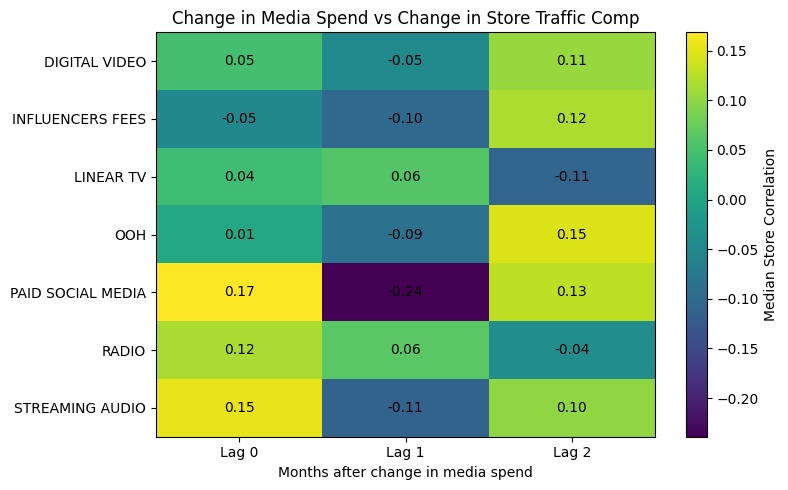

In [69]:
fig, ax = plot_lag_heatmap(
    delta_comp_lag_summary,
    outcome="Delta_Comp_Exits",
    title=(
        "Change in Media Spend vs "
        "Change in Store Traffic Comp"
    )
)

plt.show()

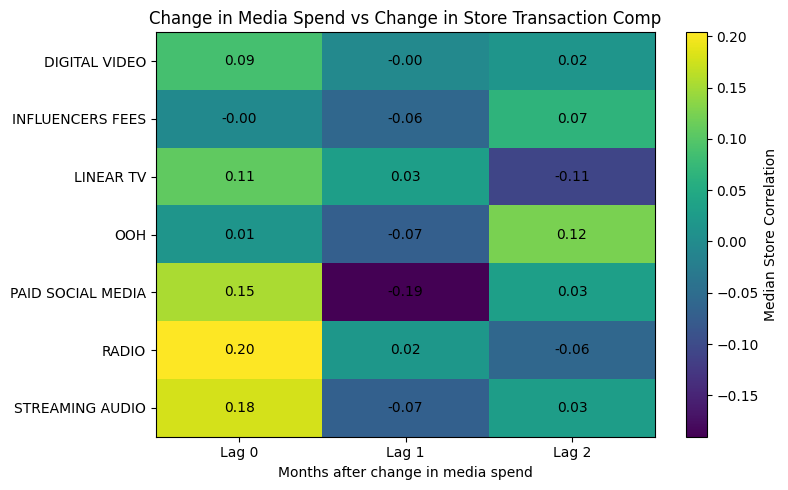

In [70]:
fig, ax = plot_lag_heatmap(
    delta_comp_lag_summary,
    outcome="Delta_Comp_Txns",
    title=(
        "Change in Media Spend vs "
        "Change in Store Transaction Comp"
    )
)

plt.show()

In [71]:
#Trend visualization

national_trend = (
    monthly_panel
    .groupby(
        "channel_Month",
        as_index=False
    )
    .agg(
        Exits=("Exits", "sum"),
        Exits_LY=("Exits_LY", "sum"),
        Sale_Txns=("Sale_Txns", "sum"),
        Sale_Txns_LY=("Sale_Txns_LY", "sum")
    )
    .sort_values("channel_Month")
)

national_trend["Comp_Exits"] = (
    (
        national_trend["Exits"]
        - national_trend["Exits_LY"]
    )
    / national_trend["Exits_LY"]
) * 100

national_trend["Comp_Txns"] = (
    (
        national_trend["Sale_Txns"]
        - national_trend["Sale_Txns_LY"]
    )
    / national_trend["Sale_Txns_LY"]
) * 100

national_trend["Delta_Comp_Exits"] = (
    national_trend["Comp_Exits"].diff()
)

national_trend["Delta_Comp_Txns"] = (
    national_trend["Comp_Txns"].diff()
)

trend_data = national_trend.merge(
    channel[
        ["channel_Month"]
        + [
            f"{c}_Change"
            for c in MEDIA_CHANNELS
        ]
    ],
    on="channel_Month",
    how="left",
    validate="one_to_one"
)



# Standarize
def zscore(series):
    return (
        series - series.mean()
    ) / series.std()


trend_data["Traffic_Change_Z"] = zscore(
    trend_data["Delta_Comp_Exits"]
)

trend_data["Txn_Change_Z"] = zscore(
    trend_data["Delta_Comp_Txns"]
)

for channel_name in MEDIA_CHANNELS:

    trend_data[
        f"{channel_name}_Change_Z"
    ] = zscore(
        trend_data[
            f"{channel_name}_Change"
        ]
    )



In [74]:
def plot_channel_traffic_trend(
    df,
    channel_name,
    outcome="Traffic",
    lag=0
):

    if outcome == "Traffic":
        outcome_col = "Traffic_Change_Z"
        outcome_label = "Traffic Comp Change"

    elif outcome == "Transactions":
        outcome_col = "Txn_Change_Z"
        outcome_label = "Transaction Comp Change"

    else:
        raise ValueError(
            "outcome must be 'Traffic' or 'Transactions'"
        )

    media_col = f"{channel_name}_Change_Z"

    plot_df = df[
        [
            "channel_Month",
            outcome_col,
            media_col
        ]
    ].copy()

    if lag > 0:
        plot_df[media_col] = (
            plot_df[media_col]
            .shift(lag)
        )

    fig, ax = plt.subplots(
        figsize=(12, 5)
    )

    ax.plot(
        plot_df["channel_Month"],
        plot_df[outcome_col],
        marker="o",
        label=outcome_label
    )

    ax.plot(
        plot_df["channel_Month"],
        plot_df[media_col],
        marker="o",
        label=(
            f"{channel_name} Spend Change "
            f"(Lag {lag})"
        )
    )

    ax.axhline(
        0,
        linewidth=1,
        alpha=0.6
    )

    ax.set_title(
        f"{channel_name}: Spend Change vs "
        f"{outcome_label} — Lag {lag}"
    )

    ax.set_xlabel("Month")
    ax.set_ylabel(
        "Standardized Monthly Change"
    )

    ax.legend()

    ax.grid(alpha=0.25)

    plt.xticks(rotation=45)
    plt.tight_layout()

    return fig, ax

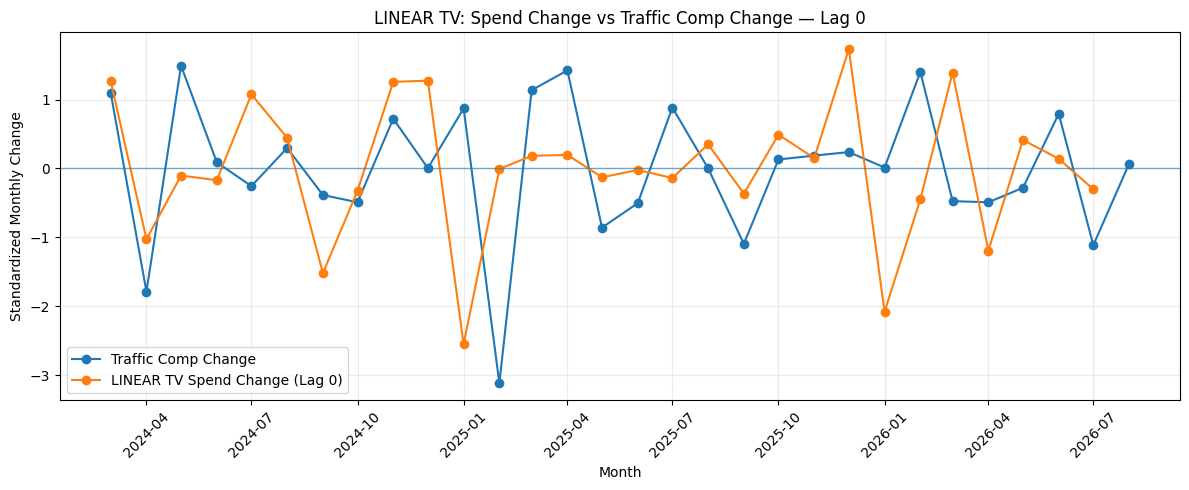

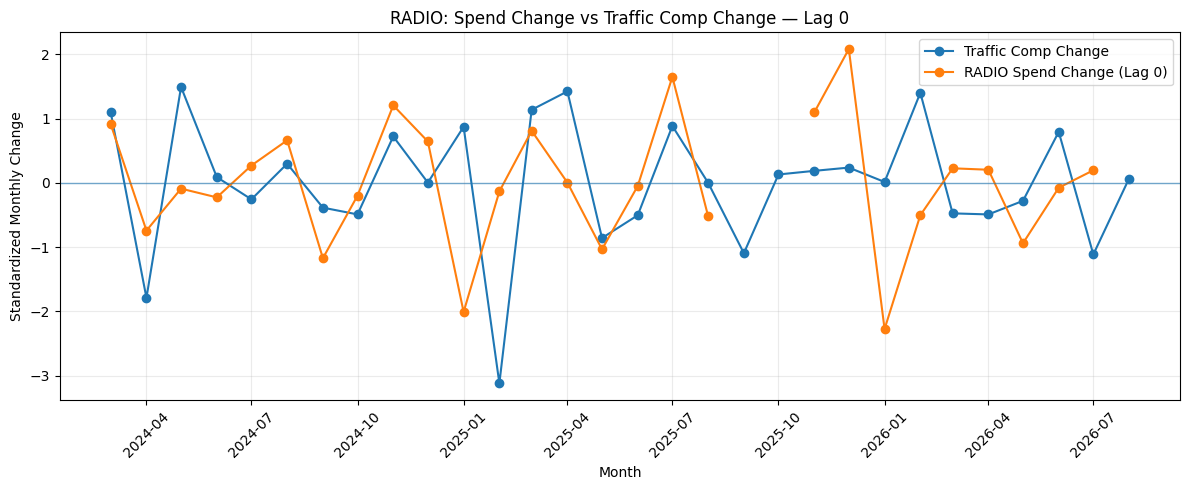

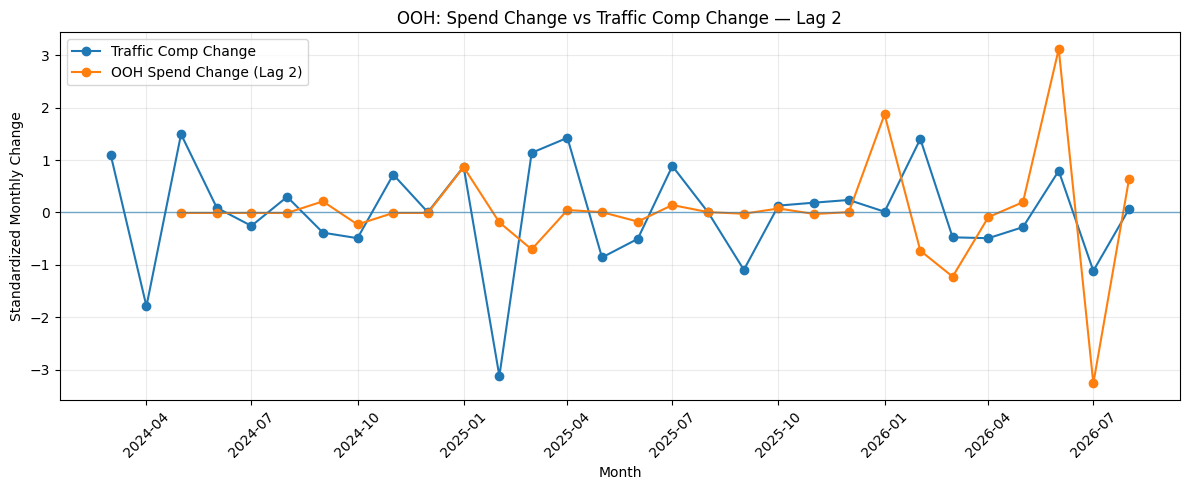

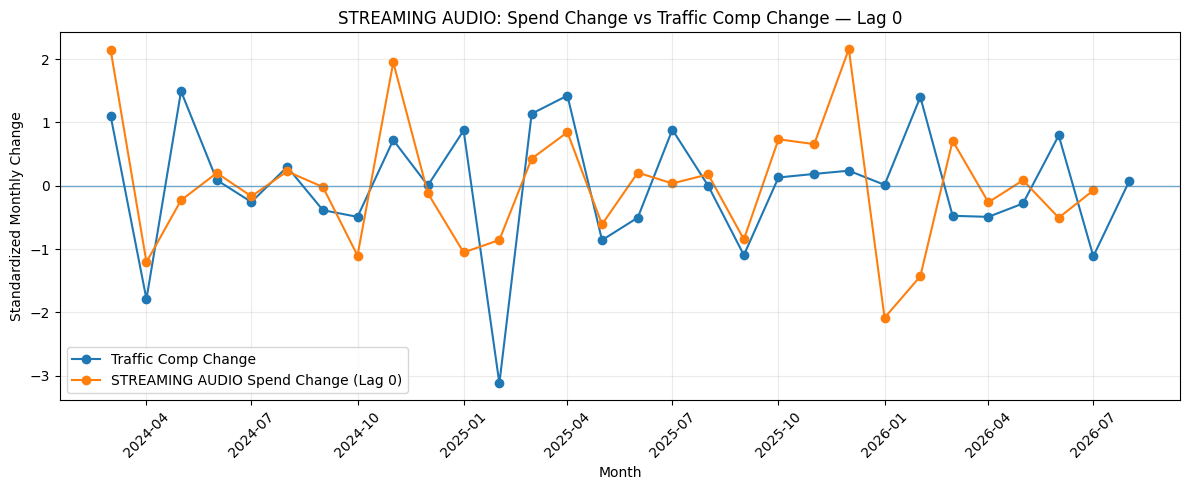

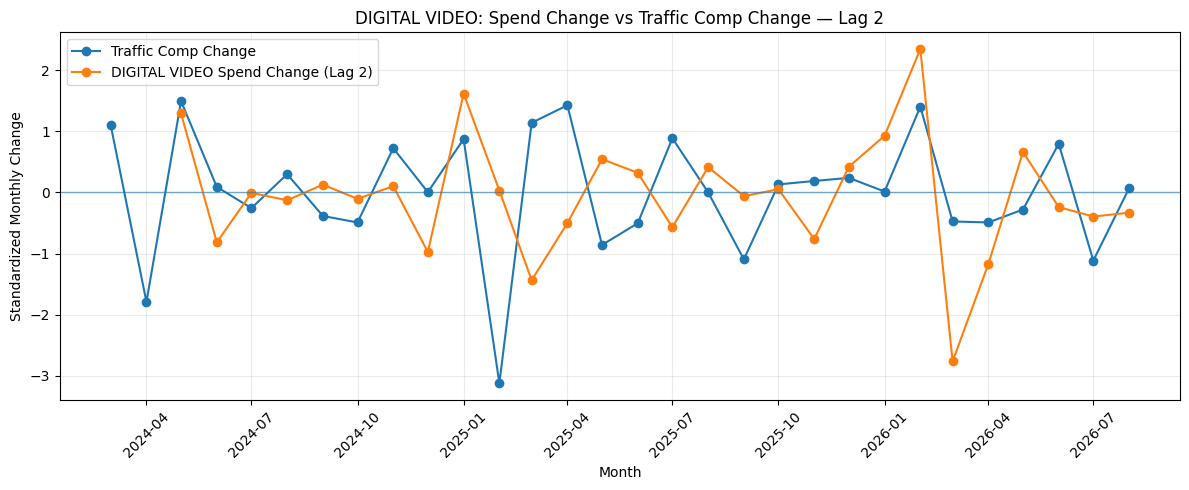

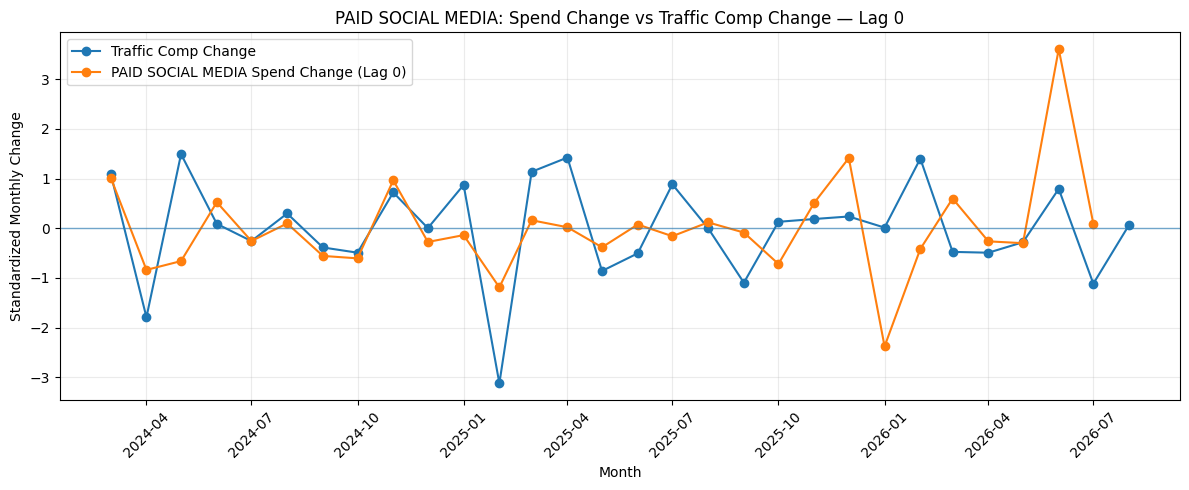

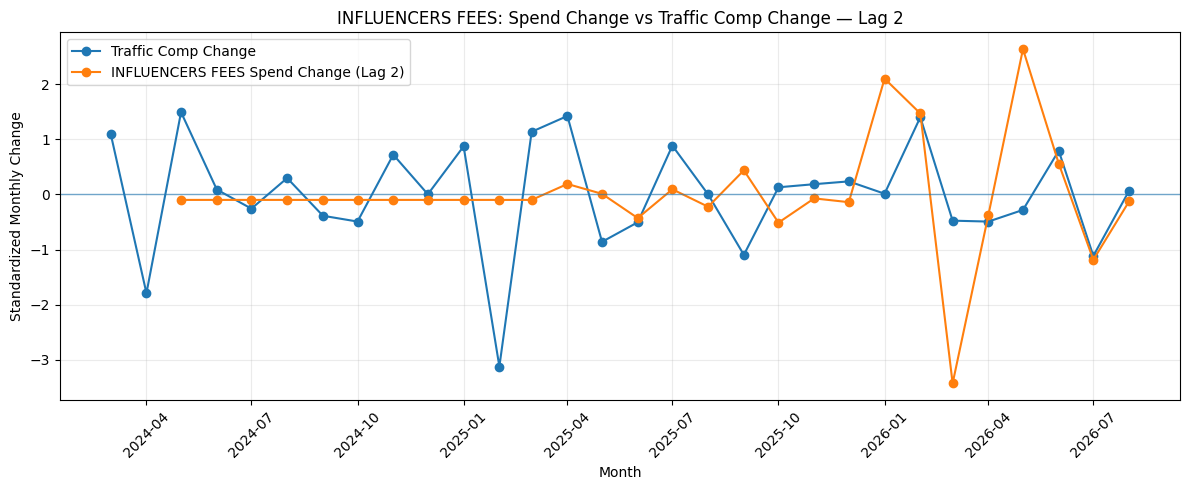

In [77]:
BEST_LAGS = {
    "LINEAR TV": 0,
    "RADIO": 0,
    "OOH": 2,
    "STREAMING AUDIO": 0,
    "DIGITAL VIDEO": 2,
    "PAID SOCIAL MEDIA": 0,
    "INFLUENCERS FEES": 2
}

for channel_name, lag in BEST_LAGS.items():

    fig, ax = plot_channel_traffic_trend(
        trend_data,
        channel_name,
        outcome="Traffic",
        lag=lag
    )

    plt.show()

In [79]:
trend_data

,channel_Month,Exits,Exits_LY,Sale_Txns,Sale_Txns_LY,Comp_Exits,Comp_Txns,Delta_Comp_Exits,Delta_Comp_Txns,LINEAR TV_Change,...,INFLUENCERS FEES_Change,Traffic_Change_Z,Txn_Change_Z,LINEAR TV_Change_Z,RADIO_Change_Z,OOH_Change_Z,STREAMING AUDIO_Change_Z,DIGITAL VIDEO_Change_Z,PAID SOCIAL MEDIA_Change_Z,INFLUENCERS FEES_Change_Z
0,2024-02-01,13476736.0,13513874.0,6257448.0,6199562.0,-0.274814,0.933711,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-03-01,24456982.0,23540449.0,11458176.0,10909478.0,3.893439,5.029553,4.168253,4.095842,597.0,...,0.0,1.099471,1.384873,1.268601,0.913139,-0.009141,2.139079,1.291928,1.020153,-0.098131
2,2024-04-01,15591847.0,16093569.0,7450625.0,7435929.0,-3.117531,0.197635,-7.010970,-4.831918,-478.0,...,0.0,-1.789731,-1.552674,-1.027135,-0.742558,-0.009141,-1.205889,-0.816575,-0.836892,-0.098131
3,2024-05-01,19140029.0,18659996.0,9145260.0,8728905.0,2.572525,4.769842,5.690056,4.572207,-45.0,...,0.0,1.492772,1.541614,-0.102434,-0.089804,-0.009141,-0.228735,-0.007438,-0.659740,-0.098131
4,2024-06-01,23905696.0,23247108.0,11148736.0,10688038.0,2.832989,4.310408,0.260464,-0.459435,-77.0,...,0.0,0.089527,-0.113973,-0.170772,-0.225678,-0.009141,0.202000,-0.128189,0.525348,-0.098131
5,2024-07-01,18915703.0,18589617.0,8477108.0,8211569.0,1.754130,3.233718,-1.078859,-1.076689,507.0,...,0.0,-0.256613,-0.317072,1.076400,0.270191,0.210934,-0.167202,0.126730,-0.256565,-0.098131
6,2024-08-01,30186138.0,29357852.0,13151508.0,12713427.0,2.821344,3.445814,1.067214,0.212095,211.0,...,0.0,0.298027,0.106984,0.444272,0.662403,-0.229216,0.226613,-0.104452,0.097739,-0.098131
7,2024-09-01,17804817.0,17586148.0,8106436.0,7994633.0,1.243416,1.398476,-1.577928,-2.047338,-709.0,...,0.0,-0.385594,-0.636449,-1.520451,-1.172591,-0.009141,-0.019521,0.101961,-0.555892,-0.098131
8,2024-10-01,17466378.0,17596880.0,8088502.0,8137778.0,-0.741620,-0.605522,-1.985036,-2.003997,-148.0,...,0.0,-0.490809,-0.622188,-0.322397,-0.199063,-0.009141,-1.102513,-0.973448,-0.604762,-0.098131
9,2024-11-01,27599028.0,27067100.0,12569291.0,12359162.0,1.965220,1.700188,2.706840,2.305710,592.0,...,0.0,0.721778,0.795857,1.257923,1.205898,0.866156,1.949555,1.614963,0.965175,-0.098131


## Reporting Layer

In [81]:
from pathlib import Path
import os

MEDIA_FIGURE_DIR = "/content/Figures"
MEDIA_TABLE_DIR = "/content/Tables"
REPORT_DIR = "/content/Reports"

TREND_FIGURE_DIR = "/content/Figures/trends"


In [82]:
import matplotlib.pyplot as plt


def save_figure(
    fig,
    filename,
    output_dir=MEDIA_FIGURE_DIR,
    dpi=300,
    close=True
):
    """
    Save a matplotlib figure using consistent report settings.
    """

    output_dir = Path(output_dir)

    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    filepath = output_dir / filename

    fig.savefig(
        filepath,
        dpi=dpi,
        bbox_inches="tight"
    )

    if close:
        plt.close(fig)

    return filepath

In [83]:
import numpy as np
import matplotlib.pyplot as plt


def plot_lag_response_heatmap(
    summary,
    outcome,
    title=None
):
    """
    Plot median store correlation by channel and lag.

    Cell annotations show:
        median correlation
        percentage of stores positive
    """

    subset = (
        summary[
            summary["Outcome"] == outcome
        ]
        .copy()
    )

    corr_matrix = (
        subset
        .pivot(
            index="Channel",
            columns="Lag",
            values="Median_Correlation"
        )
    )

    pct_matrix = (
        subset
        .pivot(
            index="Channel",
            columns="Lag",
            values="Pct_Positive"
        )
        .reindex(
            index=corr_matrix.index,
            columns=corr_matrix.columns
        )
    )

    fig, ax = plt.subplots(
        figsize=(9, 6)
    )

    vmax = np.nanmax(
        np.abs(corr_matrix.values)
    )

    im = ax.imshow(
        corr_matrix.values,
        cmap="RdBu_r",
        vmin=-vmax,
        vmax=vmax,
        aspect="auto"
    )

    ax.set_xticks(
        range(len(corr_matrix.columns))
    )

    ax.set_xticklabels(
        [
            f"Lag {lag}"
            for lag in corr_matrix.columns
        ]
    )

    ax.set_yticks(
        range(len(corr_matrix.index))
    )

    ax.set_yticklabels(
        corr_matrix.index
    )

    for i in range(
        len(corr_matrix.index)
    ):
        for j in range(
            len(corr_matrix.columns)
        ):

            corr = corr_matrix.iloc[i, j]
            pct = pct_matrix.iloc[i, j]

            ax.text(
                j,
                i,
                (
                    f"{corr:.2f}\n"
                    f"{pct:.0f}% positive"
                ),
                ha="center",
                va="center",
                fontsize=9
            )

    ax.set_xlabel(
        "Months after media spend change"
    )

    ax.set_ylabel("")

    if title is None:
        title = (
            f"Media Spend Change vs {outcome}"
        )

    ax.set_title(
        title,
        pad=15,
        fontweight="bold"
    )

    cbar = fig.colorbar(
        im,
        ax=ax
    )

    cbar.set_label(
        "Median Store Correlation"
    )

    plt.tight_layout()

    return fig, ax

In [84]:
fig, ax = plot_lag_response_heatmap(
    delta_comp_lag_summary,
    outcome="Delta_Comp_Exits",
    title=(
        "Media Spend Change vs "
        "Change in Traffic Comp"
    )
)

save_figure(
    fig,
    "lag_heatmap_exits.png"
)


fig, ax = plot_lag_response_heatmap(
    delta_comp_lag_summary,
    outcome="Delta_Comp_Txns",
    title=(
        "Media Spend Change vs "
        "Change in Transaction Comp"
    )
)

save_figure(
    fig,
    "lag_heatmap_transactions.png"
)

PosixPath('/content/Figures/lag_heatmap_transactions.png')

In [85]:
def plot_channel_overlap_heatmap(
    corr_matrix,
    title="Correlation of Monthly Media Spend Changes"
):
    """
    Plot correlation matrix for monthly changes
    in national media spend.
    """

    fig, ax = plt.subplots(
        figsize=(9, 7)
    )

    im = ax.imshow(
        corr_matrix.values,
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        aspect="auto"
    )

    labels = corr_matrix.columns

    ax.set_xticks(
        range(len(labels))
    )

    ax.set_xticklabels(
        labels,
        rotation=45,
        ha="right"
    )

    ax.set_yticks(
        range(len(labels))
    )

    ax.set_yticklabels(labels)

    for i in range(len(labels)):
        for j in range(len(labels)):

            value = corr_matrix.iloc[i, j]

            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8
            )

    ax.set_title(
        title,
        pad=15,
        fontweight="bold"
    )

    cbar = fig.colorbar(
        im,
        ax=ax
    )

    cbar.set_label(
        "Correlation"
    )

    plt.tight_layout()

    return fig, ax

In [86]:
fig, ax = plot_channel_overlap_heatmap(
    change_corr
)

save_figure(
    fig,
    "channel_overlap_heatmap.png"
)

PosixPath('/content/Figures/channel_overlap_heatmap.png')

In [87]:
def plot_channel_trend(
    df,
    channel_name,
    outcome="Traffic",
    lag=0
):
    """
    Compare standardized monthly media spend change
    with standardized change in national performance.
    """

    if outcome == "Traffic":

        outcome_col = "Traffic_Change_Z"
        outcome_label = "Traffic Comp Change"

    elif outcome == "Transactions":

        outcome_col = "Txn_Change_Z"
        outcome_label = "Transaction Comp Change"

    else:
        raise ValueError(
            "outcome must be "
            "'Traffic' or 'Transactions'"
        )

    media_col = (
        f"{channel_name}_Change_Z"
    )

    plot_df = (
        df[
            [
                "channel_Month",
                outcome_col,
                media_col
            ]
        ]
        .copy()
        .sort_values("channel_Month")
    )

    if lag > 0:
        plot_df[media_col] = (
            plot_df[media_col]
            .shift(lag)
        )

    fig, ax = plt.subplots(
        figsize=(11, 4.5)
    )

    ax.plot(
        plot_df["channel_Month"],
        plot_df[outcome_col],
        marker="o",
        linewidth=2,
        label=outcome_label
    )

    ax.plot(
        plot_df["channel_Month"],
        plot_df[media_col],
        marker="o",
        linewidth=2,
        label=(
            f"{channel_name} Spend Change"
        )
    )

    ax.axhline(
        0,
        linewidth=1,
        alpha=0.6
    )

    ax.set_title(
        (
            f"{channel_name}: "
            f"Spend Change vs {outcome_label}"
            f" — Lag {lag}"
        ),
        fontweight="bold"
    )

    ax.set_ylabel(
        "Standardized Monthly Change"
    )

    ax.set_xlabel("")

    ax.legend(
        frameon=False,
        ncol=2
    )

    ax.grid(
        axis="y",
        alpha=0.2
    )

    plt.xticks(
        rotation=45
    )

    plt.tight_layout()

    return fig, ax

In [88]:
TRAFFIC_LAGS = {
    "DIGITAL VIDEO": 2,
    "INFLUENCERS FEES": 2,
    "LINEAR TV": 1,
    "OOH": 2,
    "PAID SOCIAL MEDIA": 0,
    "RADIO": 0,
    "STREAMING AUDIO": 0,
}

TXN_LAGS = {
    "DIGITAL VIDEO": 0,
    "INFLUENCERS FEES": 2,
    "LINEAR TV": 0,
    "OOH": 2,
    "PAID SOCIAL MEDIA": 0,
    "RADIO": 0,
    "STREAMING AUDIO": 0,
}

In [89]:
def slugify_channel(channel):
    return (
        channel
        .lower()
        .replace(" ", "_")
        .replace("/", "_")
    )


def generate_trend_figures(
    trend_data,
    traffic_lags,
    txn_lags,
    output_dir=TREND_FIGURE_DIR
):
    """
    Generate and save all channel trend figures.
    """

    saved_files = []

    for channel_name, lag in traffic_lags.items():

        fig, ax = plot_channel_trend(
            trend_data,
            channel_name,
            outcome="Traffic",
            lag=lag
        )

        filename = (
            f"{slugify_channel(channel_name)}"
            f"_traffic_lag{lag}.png"
        )

        path = save_figure(
            fig,
            filename,
            output_dir=output_dir
        )

        saved_files.append(path)

    for channel_name, lag in txn_lags.items():

        fig, ax = plot_channel_trend(
            trend_data,
            channel_name,
            outcome="Transactions",
            lag=lag
        )

        filename = (
            f"{slugify_channel(channel_name)}"
            f"_transactions_lag{lag}.png"
        )

        path = save_figure(
            fig,
            filename,
            output_dir=output_dir
        )

        saved_files.append(path)

    return saved_files

In [90]:
trend_files = generate_trend_figures(
    trend_data,
    TRAFFIC_LAGS,
    TXN_LAGS
)

for path in trend_files:
    print(path)

/content/Figures/trends/digital_video_traffic_lag2.png
/content/Figures/trends/influencers_fees_traffic_lag2.png
/content/Figures/trends/linear_tv_traffic_lag1.png
/content/Figures/trends/ooh_traffic_lag2.png
/content/Figures/trends/paid_social_media_traffic_lag0.png
/content/Figures/trends/radio_traffic_lag0.png
/content/Figures/trends/streaming_audio_traffic_lag0.png
/content/Figures/trends/digital_video_transactions_lag0.png
/content/Figures/trends/influencers_fees_transactions_lag2.png
/content/Figures/trends/linear_tv_transactions_lag0.png
/content/Figures/trends/ooh_transactions_lag2.png
/content/Figures/trends/paid_social_media_transactions_lag0.png
/content/Figures/trends/radio_transactions_lag0.png
/content/Figures/trends/streaming_audio_transactions_lag0.png


In [91]:
def save_table(
    df,
    filename,
    output_dir=MEDIA_TABLE_DIR,
    index=False
):
    """
    Save a dataframe as CSV.
    """

    output_dir = Path(output_dir)

    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    filepath = output_dir / filename

    df.to_csv(
        filepath,
        index=index
    )

    return filepath

In [92]:
evidence_path = save_table(
    channel_evidence,
    "channel_evidence.csv"
)

In [93]:
lag_summary_path = save_table(
    delta_comp_lag_summary,
    "delta_comp_lag_summary.csv"
)

In [94]:
overlap_path = save_table(
    change_corr.reset_index(),
    "channel_change_correlations.csv"
)

In [96]:
pairs_path = save_table(
    change_corr_pairs,
    "channel_overlap_pairs.csv"
)

In [97]:
def create_evidence_display_table(
    channel_evidence
):
    """
    Create concise executive-facing channel evidence table.
    """

    df = channel_evidence.copy()

    df["Outcome"] = (
        df["Outcome"]
        .replace({
            "Delta_Comp_Exits": "Traffic",
            "Delta_Comp_Txns": "Transactions"
        })
    )

    df["Median_Correlation"] = (
        df["Median_Correlation"]
        .round(3)
    )

    df["Pct_Positive"] = (
        df["Pct_Positive"]
        .round(1)
    )

    df["Max_Channel_Correlation"] = (
        df["Max_Channel_Correlation"]
        .round(3)
    )

    df = df.rename(
        columns={
            "Lag": "Best Lag",
            "Median_Correlation": "Median Correlation",
            "Pct_Positive": "% Stores Positive",
            "Signal_Strength": "Signal",
            "Store_Consistency": "Consistency",
            "Max_Channel_Correlation": "Max Channel Correlation",
            "Channel_Overlap": "Overlap"
        }
    )

    return df[
        [
            "Channel",
            "Outcome",
            "Best Lag",
            "Median Correlation",
            "% Stores Positive",
            "Signal",
            "Consistency",
            "Overlap"
        ]
    ]

In [98]:
evidence_display = (
    create_evidence_display_table(
        channel_evidence
    )
)

In [99]:
def generate_media_response_outputs(
    channel_evidence,
    delta_comp_lag_summary,
    trend_data,
    change_corr,
    overlap_pairs
):
    """
    Generate all finalized media-response
    tables and figures.
    """

    # -------------------------
    # Tables
    # -------------------------

    evidence_display = (
        create_evidence_display_table(
            channel_evidence
        )
    )

    save_table(
        channel_evidence,
        "channel_evidence.csv"
    )

    save_table(
        evidence_display,
        "channel_evidence_display.csv"
    )

    save_table(
        delta_comp_lag_summary,
        "delta_comp_lag_summary.csv"
    )

    save_table(
        change_corr.reset_index(),
        "channel_change_correlations.csv"
    )

    save_table(
        overlap_pairs,
        "channel_overlap_pairs.csv"
    )

    # -------------------------
    # Lag heatmaps
    # -------------------------

    fig, _ = plot_lag_response_heatmap(
        delta_comp_lag_summary,
        "Delta_Comp_Exits",
        (
            "Media Spend Change vs "
            "Change in Traffic Comp"
        )
    )

    save_figure(
        fig,
        "lag_heatmap_exits.png"
    )

    fig, _ = plot_lag_response_heatmap(
        delta_comp_lag_summary,
        "Delta_Comp_Txns",
        (
            "Media Spend Change vs "
            "Change in Transaction Comp"
        )
    )

    save_figure(
        fig,
        "lag_heatmap_transactions.png"
    )

    # -------------------------
    # Channel overlap
    # -------------------------

    fig, _ = plot_channel_overlap_heatmap(
        change_corr
    )

    save_figure(
        fig,
        "channel_overlap_heatmap.png"
    )

    # -------------------------
    # Monthly trends
    # -------------------------

    trend_files = generate_trend_figures(
        trend_data,
        TRAFFIC_LAGS,
        TXN_LAGS
    )

    return {
        "evidence_display": evidence_display,
        "trend_files": trend_files
    }

In [100]:
report_outputs = (
    generate_media_response_outputs(
        channel_evidence=channel_evidence,
        delta_comp_lag_summary=delta_comp_lag_summary,
        trend_data=trend_data,
        change_corr=change_corr,
        overlap_pairs=change_corr_pairs
    )
)

In [110]:
import base64
import mimetypes


def image_to_data_uri(image_path):
    """
    Embed an image directly inside HTML as a data URI.
    """

    image_path = Path(image_path)

    mime_type, _ = mimetypes.guess_type(
        image_path
    )

    if mime_type is None:
        mime_type = "image/png"

    encoded = base64.b64encode(
        image_path.read_bytes()
    ).decode("utf-8")

    return (
        f"data:{mime_type};"
        f"base64,{encoded}"
    )

In [111]:
from pathlib import Path
from html import escape
import pandas as pd


# ============================================================
# HTML HELPERS
# ============================================================

def dataframe_to_html(
    df,
    classes="data-table",
    index=False
):
    """
    Convert a dataframe to report-ready HTML.
    """

    return df.to_html(
        index=index,
        classes=classes,
        border=0,
        justify="left",
        escape=True
    )


def format_lag_summary_for_report(
    delta_comp_lag_summary
):
    """
    Create a cleaner version of the full lag table
    for the report appendix.
    """

    df = delta_comp_lag_summary.copy()

    df["Outcome"] = df["Outcome"].replace({
        "Delta_Comp_Exits": "Traffic",
        "Delta_Comp_Txns": "Transactions"
    })

    df["Mean_Correlation"] = (
        df["Mean_Correlation"].round(3)
    )

    df["Median_Correlation"] = (
        df["Median_Correlation"].round(3)
    )

    df["Std_Correlation"] = (
        df["Std_Correlation"].round(3)
    )

    df["Pct_Positive"] = (
        df["Pct_Positive"].round(1)
    )

    df["Median_N_Months"] = (
        df["Median_N_Months"].round(0)
    )

    return df.rename(
        columns={
            "Mean_Correlation": "Mean Corr.",
            "Median_Correlation": "Median Corr.",
            "Std_Correlation": "Std. Corr.",
            "Pct_Positive": "% Stores Positive",
            "Store_Count": "Stores",
            "Median_N_Months": "Median Months"
        }
    )




def relative_image_path(
    image_path,
    report_path
):
    """
    Create an image path relative to the
    directory containing the HTML report.
    """

    image_path = Path(image_path).resolve()

    report_dir = (
        Path(report_path)
        .resolve()
        .parent
    )

    relative_path = os.path.relpath(
        image_path,
        start=report_dir
    )

    return Path(
        relative_path
    ).as_posix()


def image_block(
    image_path,
    report_path,
    alt_text,
    caption=None,
    css_class="report-figure",
    embed=True
):
    """
    Generate reusable HTML for a report image.
    """

    image_path = Path(image_path)

    if not image_path.exists():

        print(
            f"WARNING: Figure not found: "
            f"{image_path}"
        )

        return (
            '<div class="missing-figure">'
            f"Figure not found: "
            f"{escape(str(image_path))}"
            "</div>"
        )

    if embed:

        src = image_to_data_uri(
            image_path
        )

    else:

        src = relative_image_path(
            image_path,
            report_path
        )

    caption_html = ""

    if caption:

        caption_html = (
            f"<figcaption>"
            f"{escape(caption)}"
            f"</figcaption>"
        )

    return f"""
    <figure class="{css_class}">
        <img
            src="{src}"
            alt="{escape(alt_text)}"
        >
        {caption_html}
    </figure>
    """

In [116]:
CHANNEL_READOUTS = {
    "Paid Social": {
        "classification": "Most differentiated immediate signal",
        "text": (
            "Paid Social shows the clearest contemporaneous "
            "relationship between changes in media investment and "
            "changes in store performance. At Lag 0, median "
            "correlations are 0.169 for traffic and 0.154 for "
            "transactions, with 81.0% and 77.2% of stores, "
            "respectively, showing positive historical alignment. "
            "Channel overlap is moderate rather than high, making "
            "this one of the more differentiated signals in the analysis."
            "Business interpretation: Paid Social is most consistent with a" "short-response channel, with increased investment aligning with" "contemporaneous improvement in both comp traffic and comp" "transactions."
        )
    },

    "OOH": {
        "classification": "Most differentiated delayed signal",
        "text": (
            "OOH exhibits the clearest delayed relationship. "
            "Contemporaneous associations are essentially neutral, "
            "while both traffic and transaction relationships peak "
            "at Lag 2. Median correlations reach 0.147 and 0.124, "
            "with approximately 78% and 76% of stores showing positive "
            "alignment. OOH also has the lowest channel overlap among "
            "the primary signals, strengthening its relative "
            "identifiability."
            "Business interpretation: OOH behaves more like a delayed-response" "channel. Changes in investment are most consistently associated" "with improvement in comp traffic and comp transactions" "approximately two months later."
        )
    },

    "Radio": {
        "classification": "Suggestive immediate signal",
        "text": (
            "Radio shows a meaningful contemporaneous relationship, "
            "particularly for transactions, where the median correlation "
            "reaches 0.204 and nearly 80% of stores show positive "
            "alignment. Interpretation at the individual-channel level "
            "remains limited because Radio spend changes historically "
            "moved closely with several other media channels."
            "Business interpretation: Periods of increased Radio investment" "are associated with immediate improvement in comp performance," "particularly transactions, but the effect cannot be cleanly" "separated from the broader media mix."
        )
    },

    "Streaming Audio": {
        "classification": "Suggestive immediate signal",
        "text": (
            "Streaming Audio shows consistent contemporaneous "
            "relationships across both outcomes. Median Lag 0 "
            "correlations are 0.155 for traffic and 0.178 for "
            "transactions, with approximately 78% of stores positive. "
            "However, very high historical overlap with Digital Video "
            "and other channels substantially limits independent "
            "attribution."
            "Business interpretation: Streaming Audio is associated with" "immediate improvement in both comp traffic and comp transactions," "but the historical media plan does not provide enough independent" "variation to confidently separate its contribution from the" "surrounding media mix."
        )
    },

    "Digital Video": {
        "classification": "Suggestive but difficult to isolate",
        "text": (
            "Digital Video shows a modest delayed traffic relationship "
            "and a weaker contemporaneous transaction relationship. "
            "Its interpretation is constrained by extremely high "
            "historical overlap with Streaming Audio, making it "
            "difficult to distinguish a Digital Video-specific response."
        )
    },

    "Linear TV": {
        "classification": "Mixed evidence",
        "text": (
            "Linear TV exhibits weaker and less consistent timing. "
            "Traffic shows its strongest positive relationship at Lag 1, "
            "while transactions peak contemporaneously. Both outcomes "
            "turn negative at Lag 2. Combined with high channel overlap, "
            "the historical evidence does not support a clean "
            "channel-specific response profile."
        )
    },

    "Influencers": {
        "classification": "Inconclusive / possible delayed signal",
        "text": (
            "Influencer investment shows a possible delayed relationship, "
            "particularly for traffic at Lag 2. However, the channel was "
            "inactive during a substantial portion of the historical "
            "period and exhibits moderate overlap with other media. "
            "The result is therefore best treated as suggestive rather "
            "than a reliable channel-specific finding."
        )
    }
}

In [119]:
def build_channel_readouts(
    readouts=CHANNEL_READOUTS
):
    """
    Convert channel readouts to HTML cards.
    """

    blocks = []

    for channel, content in readouts.items():

        blocks.append(
            f"""
            <div class="channel-readout">
                <div class="channel-heading">
                    <h3>{escape(channel)}</h3>
                    <span class="classification">
                        {escape(content["classification"])}
                    </span>
                </div>

                <p>
                    {escape(content["text"])}
                </p>
            </div>
            """
        )

    return "\n".join(blocks)

In [120]:
def generate_media_response_report(
    channel_evidence,
    delta_comp_lag_summary,
    figure_dir,
    trend_figure_dir,
    report_dir,
    filename="media_response_analysis.html"
):
    """
    Generate executive-level HTML report summarizing the
    national media spend response analysis.

    Parameters
    ----------
    channel_evidence : pd.DataFrame
        Executive-facing channel evidence table.

    delta_comp_lag_summary : pd.DataFrame
        Full Channel × Outcome × Lag analytical summary.

    figure_dir : Path
        Directory containing primary report figures.

    trend_figure_dir : Path
        Directory containing monthly trend figures.

    report_dir : Path
        Directory where the HTML report will be written.

    filename : str
        HTML output filename.

    Returns
    -------
    Path
        Path to generated HTML report.
    """
    from pathlib import Path

    figure_dir = Path("/content/Figures")
    trend_figure_dir = Path("/content/Figures/trends")
    report_dir = Path("/content/Reports")



    report_path = (
        report_dir / filename
    )

    # --------------------------------------------------------
    # TABLES
    # --------------------------------------------------------

    evidence_html = dataframe_to_html(
        channel_evidence
    )

    appendix_table = (
        format_lag_summary_for_report(
            delta_comp_lag_summary
        )
    )

    appendix_html = dataframe_to_html(
        appendix_table
    )

    # --------------------------------------------------------
    # PRIMARY FIGURES
    # --------------------------------------------------------

    exits_heatmap = image_block(
        figure_dir / "lag_heatmap_exits.png",
        report_path,
        alt_text=(
            "Lagged media spend change correlations "
            "with change in traffic comp"
        ),
        caption=(
            "Median store-level correlations between monthly "
            "media spend changes and changes in traffic comp. "
            "Annotations also show the percentage of stores "
            "with positive historical alignment."
        )
    )

    txn_heatmap = image_block(
        figure_dir / "lag_heatmap_transactions.png",
        report_path,
        alt_text=(
            "Lagged media spend change correlations "
            "with change in transaction comp"
        ),
        caption=(
            "Median store-level correlations between monthly "
            "media spend changes and changes in transaction comp."
        )
    )

    overlap_heatmap = image_block(
        figure_dir / "channel_overlap_heatmap.png",
        report_path,
        alt_text=(
            "Correlation matrix of monthly media "
            "spend changes"
        ),
        caption=(
            "Correlation among monthly changes in national "
            "channel investment. High correlation indicates "
            "limited independent historical variation."
        )
    )

    # --------------------------------------------------------
    # FEATURED TREND FIGURES
    # --------------------------------------------------------

    paid_social_trend = image_block(
        trend_figure_dir
        / "paid_social_media_traffic_lag0.png",
        report_path,
        alt_text=(
            "Paid Social spend change versus "
            "traffic comp change"
        ),
        caption=(
            "Paid Social exhibits its strongest historical "
            "relationship contemporaneously."
        )
    )

    ooh_trend = image_block(
        trend_figure_dir
        / "ooh_traffic_lag2.png",
        report_path,
        alt_text=(
            "OOH spend change versus traffic "
            "comp change at a two-month lag"
        ),
        caption=(
            "OOH shows its clearest relationship approximately "
            "two months after changes in investment."
        )
    )

    radio_trend = image_block(
        trend_figure_dir
        / "radio_transactions_lag0.png",
        report_path,
        alt_text=(
            "Radio spend change versus "
            "transaction comp change"
        ),
        caption=(
            "Radio's strongest observed relationship is "
            "contemporaneous and is particularly visible "
            "for transaction performance."
        )
    )

    streaming_trend = image_block(
        trend_figure_dir
        / "streaming_audio_traffic_lag0.png",
        report_path,
        alt_text=(
            "Streaming Audio spend change versus "
            "traffic comp change"
        ),
        caption=(
            "Streaming Audio shows a consistent contemporaneous "
            "relationship, although attribution is constrained "
            "by channel overlap."
        )
    )

    # --------------------------------------------------------
    # CHANNEL READOUTS
    # --------------------------------------------------------

    channel_readouts_html = (
        build_channel_readouts()
    )



    print("\n--- FIGURE DEBUG ---")

    print("exits_heatmap type:")
    print(type(exits_heatmap))

    print("\nexits_heatmap length:")
    print(len(exits_heatmap))

    print("\nexits_heatmap start:")
    print(exits_heatmap[:200])

    print("\nContains Base64:")
    print("base64," in exits_heatmap)
    # --------------------------------------------------------
    # HTML
    # --------------------------------------------------------

    html = f"""
<!DOCTYPE html>
<html lang="en">

<head>

<meta charset="UTF-8">

<meta
    name="viewport"
    content="width=device-width, initial-scale=1.0"
>

<title>
    National Media Response Analysis
</title>

<style>

    * {{
        box-sizing: border-box;
    }}

    body {{
        margin: 0;
        background: #f4f6f8;
        color: #263238;
        font-family:
            -apple-system,
            BlinkMacSystemFont,
            "Segoe UI",
            Arial,
            sans-serif;
        line-height: 1.55;
    }}

    .report {{
        max-width: 1180px;
        margin: 0 auto;
        background: white;
        min-height: 100vh;
    }}

    /* ----------------------------------------
       HEADER
    ---------------------------------------- */

    .report-header {{
        padding: 54px 64px 42px 64px;
        border-bottom: 1px solid #dfe4e8;
    }}

    .eyebrow {{
        text-transform: uppercase;
        letter-spacing: 1.5px;
        font-size: 12px;
        font-weight: 700;
        color: #607d8b;
        margin-bottom: 10px;
    }}

    h1 {{
        margin: 0;
        font-size: 34px;
        line-height: 1.2;
        color: #17252f;
    }}

    .subtitle {{
        max-width: 820px;
        margin-top: 14px;
        font-size: 17px;
        color: #546e7a;
    }}

    /* ----------------------------------------
       SECTIONS
    ---------------------------------------- */

    section {{
        padding: 42px 64px;
        border-bottom: 1px solid #e6eaed;
    }}

    h2 {{
        margin-top: 0;
        margin-bottom: 12px;
        font-size: 24px;
        color: #1c313a;
    }}

    h3 {{
        margin-top: 0;
        margin-bottom: 5px;
        font-size: 17px;
    }}

    .section-intro {{
        max-width: 900px;
        color: #607d8b;
        margin-bottom: 26px;
    }}

    /* ----------------------------------------
       EXECUTIVE SUMMARY
    ---------------------------------------- */

    .summary-grid {{
        display: grid;
        grid-template-columns:
            repeat(4, minmax(0, 1fr));
        gap: 16px;
        margin-top: 28px;
    }}

    .summary-card {{
        padding: 20px;
        border: 1px solid #dfe5e8;
        border-radius: 8px;
        background: #fafbfc;
    }}

    .summary-card .label {{
        font-size: 12px;
        text-transform: uppercase;
        letter-spacing: .7px;
        font-weight: 700;
        color: #78909c;
    }}

    .summary-card .value {{
        margin-top: 8px;
        font-size: 19px;
        font-weight: 700;
        color: #263238;
    }}

    .summary-card p {{
        font-size: 13px;
        color: #607d8b;
        margin-bottom: 0;
    }}

    .key-takeaway {{
        margin-top: 28px;
        padding: 20px 24px;
        border-left: 4px solid #455a64;
        background: #f5f7f8;
        font-size: 16px;
    }}

    /* ----------------------------------------
       TABLES
    ---------------------------------------- */

    .table-wrapper {{
        overflow-x: auto;
        margin-top: 22px;
    }}

    table.data-table {{
        width: 100%;
        border-collapse: collapse;
        font-size: 13px;
    }}

    table.data-table th {{
        background: #eef2f4;
        color: #37474f;
        text-align: left;
        font-weight: 700;
        padding: 10px 9px;
        border-bottom: 2px solid #cfd8dc;
        white-space: nowrap;
    }}

    table.data-table td {{
        padding: 9px;
        border-bottom: 1px solid #e4e8ea;
        vertical-align: top;
    }}

    table.data-table tr:nth-child(even) {{
        background: #fafbfb;
    }}

    /* ----------------------------------------
       FIGURES
    ---------------------------------------- */

    .figure-grid {{
        display: grid;
        grid-template-columns:
            repeat(2, minmax(0, 1fr));
        gap: 26px;
    }}

    .report-figure {{
        margin: 0;
        min-width: 0;
    }}

    .report-figure img {{
        display: block;
        width: 100%;
        height: auto;
    }}

    figcaption {{
        margin-top: 9px;
        font-size: 12px;
        line-height: 1.45;
        color: #78909c;
    }}

    .full-width-figure {{
        margin: 10px auto 0 auto;
        max-width: 920px;
    }}

    .missing-figure {{
        padding: 30px;
        border: 1px dashed #b0bec5;
        color: #78909c;
        text-align: center;
    }}

    /* ----------------------------------------
       CHANNEL READOUTS
    ---------------------------------------- */

    .channel-readout {{
        padding: 20px 0;
        border-bottom: 1px solid #e5e9eb;
    }}

    .channel-readout:last-child {{
        border-bottom: none;
    }}

    .channel-heading {{
        display: flex;
        align-items: baseline;
        gap: 14px;
        flex-wrap: wrap;
    }}

    .classification {{
        font-size: 12px;
        font-weight: 700;
        color: #607d8b;
        text-transform: uppercase;
        letter-spacing: .5px;
    }}

    .channel-readout p {{
        max-width: 900px;
        margin-bottom: 0;
        color: #455a64;
    }}

    /* ----------------------------------------
       METHODOLOGY
    ---------------------------------------- */

    .method-flow {{
        display: flex;
        flex-wrap: wrap;
        align-items: center;
        gap: 8px;
        margin-top: 24px;
    }}

    .method-step {{
        padding: 9px 13px;
        border-radius: 5px;
        background: #eef2f4;
        font-size: 13px;
        font-weight: 600;
    }}

    .arrow {{
        color: #90a4ae;
    }}

    /* ----------------------------------------
       LIMITATIONS
    ---------------------------------------- */

    .limitations {{
        background: #fafbfc;
    }}

    .limitations ul {{
        padding-left: 20px;
        max-width: 920px;
    }}

    .limitations li {{
        margin-bottom: 10px;
    }}

    /* ----------------------------------------
       APPENDIX
    ---------------------------------------- */

    details {{
        margin-top: 18px;
    }}

    summary {{
        cursor: pointer;
        font-weight: 700;
        padding: 12px 0;
    }}

    /* ----------------------------------------
       FOOTER
    ---------------------------------------- */

    footer {{
        padding: 30px 64px 42px;
        font-size: 12px;
        color: #90a4ae;
    }}

    /* ----------------------------------------
       RESPONSIVE
    ---------------------------------------- */

    @media (max-width: 850px) {{

        .report-header,
        section,
        footer {{
            padding-left: 28px;
            padding-right: 28px;
        }}

        .summary-grid {{
            grid-template-columns:
                repeat(2, minmax(0, 1fr));
        }}

        .figure-grid {{
            grid-template-columns: 1fr;
        }}
    }}

    /* ----------------------------------------
       PRINT / PDF
    ---------------------------------------- */

    @media print {{

        body {{
            background: white;
        }}

        .report {{
            max-width: none;
        }}

        section {{
            break-inside: avoid;
        }}

        .channel-readout {{
            break-inside: avoid;
        }}

        .report-figure {{
            break-inside: avoid;
        }}

        details {{
            display: block;
        }}

        details > * {{
            display: block;
        }}
    }}

</style>

</head>

<body>

<div class="report">


<!-- ======================================================
     HEADER
======================================================= -->

<header class="report-header">

    <div class="eyebrow">
        Media Incrementality Analysis
    </div>

    <h1>
        National Media Response Analysis
    </h1>

    <div class="subtitle">
        Historical assessment of how changes in national
        media investment align with changes in store traffic
        and transaction performance, including response timing,
        consistency across stores, and channel overlap.
    </div>

</header>


<!-- ======================================================
     EXECUTIVE SUMMARY
======================================================= -->

<section>

    <h2>Executive Summary</h2>

    <p class="section-intro">
        This analysis evaluates how changes in national marketing investment align with changes in comp traffic and comp transaction performance across the store base. Rather than focusing on absolute spend levels, the analysis measures whether increases or decreases in channel investment are associated with subsequent improvement or deterioration in year-over-year store performance.

        The results indicate that marketing response differs meaningfully by channel and by timing. Paid Social demonstrates the clearest immediate relationship with both comp traffic and comp transactions, while OOH demonstrates the clearest delayed relationship, with its strongest alignment appearing approximately two months after changes in investment. Radio and Streaming Audio also exhibit meaningful contemporaneous relationships, particularly with comp transactions, although their historical co-campaign timing alongside other media channels limits channel-specific attribution.

        Overall, the evidence suggests that changes in the marketing mix are associated with measurable movement in comp performance, but the strength and timing of that relationship vary by channel. The clearest differentiated signals are Paid Social for immediate response and OOH for delayed response. Results for Radio, Streaming Audio, Digital Video, and Linear TV should be interpreted more cautiously because these channels historically moved together (co-correlated), making their individual contributions difficult to isolate.

        These findings represent historical media-response relationships rather than causal estimates of incremental return. They are most useful for understanding channel response patterns, informing future media planning, and identifying where more controlled testing could improve channel-level attribution.
    </p>

    <div class="summary-grid">

        <div class="summary-card">
            <div class="label">
                Clearest Immediate Signal
            </div>

            <div class="value">
                Paid Social
            </div>

            <p>
                Strong contemporaneous alignment across
                both traffic and transactions.
            </p>
        </div>

        <div class="summary-card">
            <div class="label">
                Clearest Delayed Signal
            </div>

            <div class="value">
                OOH — Lag 2
            </div>

            <p>
                Consistent two-month relationship with
                relatively low channel overlap.
            </p>
        </div>

        <div class="summary-card">
            <div class="label">
                Strongest Transaction Signal
            </div>

            <div class="value">
                Radio
            </div>

            <p>
                Median contemporaneous correlation of
                approximately 0.20, but attribution is limited
                by high channel overlap.
            </p>
        </div>

        <div class="summary-card">
            <div class="label">
                Primary Constraint
            </div>

            <div class="value">
                Channel Overlap
            </div>

            <p>
                Several major channels historically moved
                together, limiting individual attribution.
            </p>
        </div>

    </div>

    <div class="key-takeaway">
        <strong>Key takeaway:</strong>
        Changes in media investment show modest but measurable
        relationships with changes in store performance.
        Paid Social provides the clearest immediate
        channel-specific signal, while OOH provides the clearest
        differentiated delayed signal. These relationships are
        associative and should not be interpreted as causal
        estimates of incremental media impact.
    </div>

</section>


<!-- ======================================================
     EVIDENCE SCORECARD
======================================================= -->

<section>

    <h2>Channel Evidence Scorecard</h2>

    <p class="section-intro">
        The table below summarizes each channel's strongest observed relationship with comp traffic and comp transactions. The best lag identifies when changes in channel investment most closely align with changes in comp performance, while store consistency indicates how broadly that directional relationship appears across the store base.

        Because national media investment does not vary by store, store consistency should be interpreted as evidence that a relationship is geographically broad—not as additional independent media observations. Channel overlap provides an additional measure of how confidently the observed relationship can be distinguished from changes in other marketing channels.
    </p>

    <div class="table-wrapper">
        {evidence_html}
    </div>

</section>


<!-- ======================================================
     METHODOLOGY
======================================================= -->

<section>

    <h2>Analytical Approach</h2>

    <p class="section-intro">
        The analysis progressively removed persistent levels and
        examined whether changes in media investment align with
        subsequent changes in store performance.
    </p>

    <div class="method-flow">

        <span class="method-step">
            Absolute Spend
        </span>

        <span class="arrow">→</span>

        <span class="method-step">
            Δ Media Spend
        </span>

        <span class="arrow">→</span>

        <span class="method-step">
            Δ Store Comp
        </span>

        <span class="arrow">→</span>

        <span class="method-step">
            Lag 0 / 1 / 2
        </span>

        <span class="arrow">→</span>

        <span class="method-step">
            Store Consistency
        </span>

        <span class="arrow">→</span>

        <span class="method-step">
            Channel Overlap
        </span>

        <span class="arrow">→</span>

        <span class="method-step">
            Trend Validation
        </span>

    </div>

</section>


<!-- ======================================================
     LAG RESPONSE
======================================================= -->

<section>

    <h2>Media Response Timing</h2>

    <p class="section-intro">
        Marketing response is not uniform across channels. The lag analysis indicates two distinct patterns in the historical data.

        Paid Social, Radio, and Streaming Audio exhibit their strongest relationships contemporaneously, suggesting that changes in these investments are most closely associated with changes in comp performance during the same month. Paid Social shows particularly broad alignment across both comp traffic and comp transactions, while Radio's strongest relationship appears in transaction performance.

        OOH exhibits a different pattern. Its contemporaneous relationship is minimal, while substantially stronger and more consistent relationships emerge approximately two months after changes in investment. This delayed pattern appears in both comp traffic and comp transactions.

        Digital Video, Linear TV, and Influencer investment show less consistent timing. While positive relationships emerge at selected lags, the combination of weaker response magnitude, sparse activation, or substantial overlap with other channels makes their individual response profiles less conclusive.
    </p>

    <div class="figure-grid">

        {exits_heatmap}

        {txn_heatmap}

    </div>

</section>


<!-- ======================================================
     MONTHLY TRENDS
======================================================= -->

<section>

    <h2>Monthly Trend Validation</h2>

    <p class="section-intro">
        Standardized monthly series provide a visual check on
        whether the statistical relationships persist through time
        or appear to be driven primarily by isolated months.
        Media series are shifted according to the strongest
        observed response lag.
    </p>

    <div class="figure-grid">

        {paid_social_trend}

        {ooh_trend}

        {radio_trend}

        {streaming_trend}

    </div>

</section>


<!-- ======================================================
     CHANNEL OVERLAP
======================================================= -->

<section>

    <h2>Channel Overlap and Attribution</h2>

    <p class="section-intro">
        National media channels were frequently deployed together.
        This limits the ability of historical observational data to
        separate the contribution of individual channels, even when
        a consistent performance relationship is observed.
    </p>

    <div class="full-width-figure">
        {overlap_heatmap}
    </div>

    <div class="key-takeaway">
        Linear TV, Radio, Streaming Audio, and Digital Video form
        a particularly correlated media cluster. Results for these
        channels should therefore be interpreted as evidence of
        media-response association rather than independently
        identified channel effects.
    </div>

</section>


<!-- ======================================================
     CHANNEL READOUTS
======================================================= -->

<section>

    <h2>Channel-Level Readouts</h2>

    <p class="section-intro">
        Channel interpretations reflect the combined evidence from
        response magnitude, timing, store-level directional
        consistency, and channel independence.
    </p>

    {channel_readouts_html}

</section>

<!-- ======================================================
     Conclusion
======================================================= -->

<section>

    <h2>Conclusion</h2>

    <p class="section-intro">
        The analysis provides evidence that changes in national marketing investment are associated with changes in year-over-year store performance, but the magnitude, timing, and identifiability of that relationship differ materially by channel.

        The clearest immediate relationship is observed for Paid Social, where increased investment aligns with contemporaneous improvement in both comp traffic and comp transactions across a broad share of stores. OOH provides the clearest delayed relationship, with improvement in both performance measures appearing most consistently approximately two months after changes in investment.

        Radio and Streaming Audio also demonstrate meaningful immediate relationships, particularly with comp transactions. However, these channels historically moved closely with other media investments, limiting the ability to assign the observed performance movement to an individual channel. Digital Video and Linear TV provide weaker or less consistent independent evidence, while Influencer investment remains suggestive but inconclusive because of its intermittent activation.

        Taken together, the results support a marketing-response framework rather than a uniform channel-impact model. Different channels appear to operate on different response timelines, and the historical media plan provides substantially better attribution for some channels than others.

        For planning purposes, Paid Social and OOH provide the strongest differentiated historical signals. Radio and Streaming Audio should be viewed as promising components of the broader media mix, but additional independent variation or controlled testing would be required to estimate their standalone incremental contribution with greater confidence.
    </p>

</section>


<!-- ======================================================
     LIMITATIONS
======================================================= -->

<section class="limitations">

    <h2>Limitations and Appropriate Use</h2>

    <ul>

        <li>
            Media investment varies nationally by month.
            The effective number of independent media periods is
            therefore the number of observed national months—not
            the number of store-month observations.
        </li>

        <li>
            Store-level consistency describes how broadly a
            relationship appears across locations but does not
            create independent media treatment observations.
        </li>

        <li>
            Several media channels historically moved together,
            particularly Linear TV, Radio, Streaming Audio, and
            Digital Video. Individual channel attribution within
            this cluster is therefore limited.
        </li>

        <li>
            Some channels, particularly Influencer investment,
            contain substantial zero-spend periods and therefore
            have fewer independent activation periods.
        </li>

        <li>
            Lag relationships may reflect response timing,
            campaign pulsing, seasonality, or mean reversion.
            They should not be interpreted as independently
            estimated causal effects.
        </li>

        <li>
            Results identify historical media-response
            associations and should not be interpreted as direct
            estimates of incremental return on media investment.
        </li>

    </ul>

</section>


<!-- ======================================================
     APPENDIX
======================================================= -->

<section>

    <h2>Appendix</h2>

    <p class="section-intro">
        Detailed lag results are retained below for analytical
        review while keeping the primary report focused on
        executive-level findings.
    </p>

    <details>

        <summary>
            Full Channel × Outcome × Lag Results
        </summary>

        <div class="table-wrapper">
            {appendix_html}
        </div>

    </details>

</section>


<footer>

    National Media Response Analysis ·
    Historical observational analysis ·
    Associations should not be interpreted as causal estimates.

</footer>


</div>

</body>
</html>
"""

    # --------------------------------------------------------
    # WRITE REPORT
    # --------------------------------------------------------

    report_path.write_text(
        html,
        encoding="utf-8"
    )

    print(
        f"Media response report saved to:\n"
        f"{report_path}"
    )

    return report_path

In [121]:
report_path = generate_media_response_report(
    channel_evidence=evidence_display,
    delta_comp_lag_summary=delta_comp_lag_summary,
    figure_dir=MEDIA_FIGURE_DIR,
    trend_figure_dir=TREND_FIGURE_DIR,
    report_dir=REPORT_DIR
)


--- FIGURE DEBUG ---
exits_heatmap type:
<class 'str'>

exits_heatmap length:
424292

exits_heatmap start:

    <figure class="report-figure">
        <img
            src="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAACjAAAAblCAYAAACUjhmlAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8v

Contains Base64:
True
Media response report saved to:
/content/Reports/media_response_analysis.html
